## DSC-NUCLIO_E01_DataPreparation
### PROFESOR_AlbertoVacas PROJECT_BMWPricing GRUPO_03


### IMPORTAMOS LIBRERÍAS Y LEEMOS EL FICHERO


In [1]:
# IMPORTAMOS LIBRERÍAS NECESARIAS PARA EL ANÁLISIS
# pandas: para manipulación de datos
# numpy: para operaciones numéricas
# matplotlib y seaborn: para visualizaciones
# sklearn: para preprocesamiento de datos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

# Configuramos el estilo de las visualizaciones
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


In [2]:
# LEEMOS EL FICHERO DE BMW PRICING
# El dataset contiene información sobre vehículos BMW usados con sus características y precios

df_bmw = pd.read_csv("bmw_pricing.csv", sep=",")
df_bmw.head()


,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
0,NaN,118,140411.0,100.0,2012-02-01,diesel,black,NaN,True,True,False,NaN,True,NaN,True,NaN,11300.0,2018-01-01
1,BMW,M4,13929.0,317.0,NaN,petrol,grey,convertible,True,True,False,NaN,False,True,True,True,69700.0,2018-02-01
2,BMW,320,183297.0,120.0,2012-04-01,diesel,white,NaN,False,False,False,NaN,True,False,True,False,10200.0,2018-02-01
3,BMW,420,128035.0,135.0,NaN,diesel,red,convertible,True,True,False,NaN,True,True,True,NaN,25100.0,2018-02-01
4,BMW,425,97097.0,160.0,NaN,diesel,silver,NaN,True,True,False,False,False,True,True,True,33400.0,2018-04-01


### PARTE 1: LIMPIEZA Y PREPARACIÓN DE DATOS


#### ANÁLISIS INICIAL DEL DATASET


In [3]:
# Obtenemos información general del dataset: tipos de datos, número de filas y columnas
# Esto nos ayuda a entender la estructura inicial de los datos

df_bmw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   marca                        3873 non-null   object 
 1   modelo                       4840 non-null   object 
 2   km                           4841 non-null   float64
 3   potencia                     4842 non-null   float64
 4   fecha_registro               2420 non-null   object 
 5   tipo_gasolina                4838 non-null   object 
 6   color                        4398 non-null   object 
 7   tipo_coche                   3383 non-null   object 
 8   volante_regulable            4839 non-null   object 
 9   aire_acondicionado           4357 non-null   object 
 10  camara_trasera               4841 non-null   object 
 11  asientos_traseros_plegables  1452 non-null   object 
 12  elevalunas_electrico         4841 non-null   object 
 13  bluetooth         

In [4]:
# Verificamos la forma del dataset (número de filas y columnas)
print(f"Dimensiones del dataset: {df_bmw.shape}")


Dimensiones del dataset: (4843, 18)


#### PREGUNTA 1: ¿QUÉ VARIABLES TIENEN NULOS?


In [5]:
# Identificamos qué columnas tienen valores nulos y cuántos
# Esto es crucial para decidir cómo manejar los valores faltantes

df_bmw.isnull().sum()


marca                           970
modelo                            3
km                                2
potencia                          1
fecha_registro                 2423
tipo_gasolina                     5
color                           445
tipo_coche                     1460
volante_regulable                 4
aire_acondicionado              486
camara_trasera                    2
asientos_traseros_plegables    3391
elevalunas_electrico              2
bluetooth                       728
gps                               0
alerta_lim_velocidad            728
precio                            6
fecha_venta                       1
dtype: int64

In [6]:
# Calculamos el porcentaje de nulos por columna para tener una mejor perspectiva
# Un porcentaje alto de nulos puede indicar que una columna no es útil para el análisis

porcentaje_nulos = (df_bmw.isnull().sum() / len(df_bmw)) * 100
porcentaje_nulos = porcentaje_nulos.sort_values(ascending=False)
porcentaje_nulos


asientos_traseros_plegables    70.018584
fecha_registro                 50.030973
tipo_coche                     30.146603
marca                          20.028908
alerta_lim_velocidad           15.032005
bluetooth                      15.032005
aire_acondicionado             10.035102
color                           9.188520
precio                          0.123890
tipo_gasolina                   0.103242
volante_regulable               0.082593
modelo                          0.061945
elevalunas_electrico            0.041297
km                              0.041297
camara_trasera                  0.041297
potencia                        0.020648
fecha_venta                     0.020648
gps                             0.000000
dtype: float64

#### ELIMINACIÓN INICIAL DE COLUMNAS

**Decisión:** Antes de proceder con el análisis, debemos identificar columnas que no aportan valor o que tienen demasiados nulos


In [7]:
# Analizamos la columna 'marca'. Si todos los valores son BMW o nulos, no aporta información
# La mayoría de los registros deberían ser BMW, pero hay algunos nulos
print(df_bmw['marca'].value_counts(dropna=False))


marca
BMW    3873
NaN     970
Name: count, dtype: int64


In [8]:
# Analizamos 'asientos_traseros_plegables' que tiene más del 70% de nulos
# Esta columna tiene demasiados valores faltantes para ser útil
print(df_bmw['asientos_traseros_plegables'].value_counts(dropna=False))


asientos_traseros_plegables
NaN      3391
False    1150
True      302
Name: count, dtype: int64


In [9]:
# Creamos una copia del dataset para trabajar sin modificar el original
df_bmw_clean = df_bmw.copy()

# DECISIÓN: Eliminamos columnas que no aportan valor:
# 1. 'marca': Todos los coches son BMW (o deberían serlo), no aporta información discriminativa
# 2. 'asientos_traseros_plegables': Tiene más del 70% de nulos, no es útil para el modelo

columnas_eliminar = ['marca', 'asientos_traseros_plegables']
df_bmw_clean = df_bmw_clean.drop(columns=columnas_eliminar)
df_bmw_clean.shape


(4843, 16)

#### CONVERSIÓN DE FECHAS A FORMATO DATETIME


In [10]:
# Convertimos las columnas de fecha a formato datetime para poder trabajar con ellas

df_bmw_clean['fecha_registro'] = pd.to_datetime(df_bmw_clean['fecha_registro'], errors='coerce')
df_bmw_clean['fecha_venta'] = pd.to_datetime(df_bmw_clean['fecha_venta'], errors='coerce')

# Verificamos la conversión
df_bmw_clean[['fecha_registro', 'fecha_venta']].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   fecha_registro  2420 non-null   datetime64[ns]
 1   fecha_venta     4842 non-null   datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 75.8 KB


#### ELIMINACIÓN DE DUPLICADOS


In [11]:
# Identificamos registros duplicados
# Los duplicados pueden sesgar nuestro análisis y modelo

duplicados = df_bmw_clean.duplicated()
duplicados.sum()


np.int64(0)

In [12]:
# En el caso de tener duplicados los eliminaríamos y resetearíamos el índice
df_bmw_clean = df_bmw_clean.drop_duplicates().reset_index(drop=True)

# Luego podríamos calcular el número de registros eliminados
df_bmw.shape[0] - df_bmw_clean.shape[0]


0

#### CREACIÓN DE VARIABLES DERIVADAS


In [13]:
# Creamos una variable que puede ser útil para el modelo:
# 1. EDAD_VEHICULO: años desde el registro hasta la venta (puede ayudar a predecir precio)

# Calculamos la edad del vehículo en años al momento de la venta
df_bmw_clean['EDAD_VEHICULO'] = (df_bmw_clean['fecha_venta'] - df_bmw_clean['fecha_registro']).dt.days / 365

# Verificamos la nueva variable
df_bmw_clean['EDAD_VEHICULO'].describe()


count    2420.000000
mean        5.389322
std         2.528404
min        -5.504110
25%         4.079452
50%         4.838356
75%         5.835616
max        28.104110
Name: EDAD_VEHICULO, dtype: float64

#### PREGUNTA 2: TRATAMIENTO DE NULOS POR COLUMNA

Analizamos cada columna con nulos y decidimos la estrategia de imputación o eliminación.


In [14]:
# Revisamos nuevamente los nulos después de las transformaciones iniciales

nulos_actualizados = df_bmw_clean.isnull().sum()
nulos_actualizados = nulos_actualizados[nulos_actualizados > 0].sort_values(ascending=False)
nulos_actualizados


fecha_registro          2423
EDAD_VEHICULO           2423
tipo_coche              1460
bluetooth                728
alerta_lim_velocidad     728
aire_acondicionado       486
color                    445
precio                     6
tipo_gasolina              5
volante_regulable          4
modelo                     3
km                         2
elevalunas_electrico       2
camara_trasera             2
potencia                   1
fecha_venta                1
dtype: int64

**Estrategia para nulos por columna:**

1. **precio (target)**: Eliminaremos registros con precio nulo ya que no podemos predecir sin target
2. **modelo/km/potencia**: Son variables numéricas críticas. Tienen pocos nulos. Tiene sentido eliminar o imputar con mediana/moda según corresponda
3. **fecha_registro**: Tiene aprox 50% nulos. Tiene sentido crear variable binaria "fecha_registro_disponible" o imputar con mediana
4. **tipo_gasolina**: Imputaremos con moda (valor más frecuente)
5. **tipo_coche**: Tiene aprox 30% nulos. Tiene sentido imputar con moda o crear categoría "desconocido"
6. **color**: Tiene aprox 9% nulos. Tiene sentido imputar con moda o crear categoría "desconocido"
7. **VARIABLES BOOLEANAS**: bluetooth, alerta_lim_velocidad, aire_acondicionado, volante_regulable, camara_trasera, elevalunas_electrico. Estas variables tienen valores True/False/NaN. Tratamos NaN como False (ausencia de característica)
8. **gps**: Ya es booleano, verificamos que no tenga nulos
9. **fecha_venta**: Eliminamos si falta (es crítica y solo hay un valor nulo)
10. **fecha_registro**: Tiene aprox 50% nulos. Hay que pensar en una estrategia inteligente ya que
no podemos imputar media al 50% de los datos, ni eliminar el 50% de los registros




In [15]:
# 1. precio (target): Eliminamos registros sin precio
# No podemos usar registros sin precio para entrenar el modelo

print(f"Registros antes de eliminar nulos en precio: {len(df_bmw_clean)}")
df_bmw_clean = df_bmw_clean.dropna(subset=['precio'])
print(f"Registros despues: {len(df_bmw_clean)}")
print(f"Registros eliminados: {df_bmw.shape[0] - len(df_bmw_clean)}")


Registros antes de eliminar nulos en precio: 4843
Registros despues: 4837
Registros eliminados: 6


In [16]:
# 2. modelo, km, potencia
# Estas son variables importantes, eliminamos si faltan valores críticos

print("Nulos en variables numéricas críticas:")
print(f"modelo: {df_bmw_clean['modelo'].isnull().sum()}")
print(f"km: {df_bmw_clean['km'].isnull().sum()}")
print(f"potencia: {df_bmw_clean['potencia'].isnull().sum()}")

# Eliminamos registros sin modelo, km o potencia ya que són pocas
df_bmw_clean = df_bmw_clean.dropna(subset=['modelo', 'km', 'potencia'])
print(f"Registros después de eliminar nulos en variables críticas: {len(df_bmw_clean)}")


Nulos en variables numéricas críticas:
modelo: 3
km: 2
potencia: 1
Registros después de eliminar nulos en variables críticas: 4831


In [17]:
# 3. fecha_registro: Crear variable binaria y mantener nulos
# Como tiene muchos nulos (aprox 50%), creamos una variable indicadora
# Para EDAD_VEHICULO, los nulos se mantienen (serán NaN) y los trataremos después

df_bmw_clean['fecha_registro_disponible'] = df_bmw_clean['fecha_registro'].notna().astype(int)
df_bmw_clean['fecha_registro_disponible'].value_counts()

fecha_registro_disponible
1    2416
0    2415
Name: count, dtype: int64

In [18]:
# 4. tipo_gasolina: Imputamos con moda (valor más frecuente)
# Es una variable categórica importante

moda_tipo_gasolina = df_bmw_clean['tipo_gasolina'].mode()[0]
print(f"Moda de tipo_gasolina: {moda_tipo_gasolina}")
print(f"Nulos antes: {df_bmw_clean['tipo_gasolina'].isnull().sum()}")

df_bmw_clean['tipo_gasolina'] = df_bmw_clean['tipo_gasolina'].fillna(moda_tipo_gasolina)
print(f"Nulos despues: {df_bmw_clean['tipo_gasolina'].isnull().sum()}")


Moda de tipo_gasolina: diesel
Nulos antes: 5
Nulos despues: 0


In [19]:
# 5. tipo_coche: Imputar con moda o crear categoría "desconocido"
# Tiene aprox 30% de nulos, pero es una variable importante, 
# por lo que deicidimos crear categoría "desconocido" en lugar de imputar con moda

print(df_bmw_clean['tipo_coche'].value_counts(dropna=False))
df_bmw_clean['tipo_coche'] = df_bmw_clean['tipo_coche'].fillna('desconocido')

print(df_bmw_clean['tipo_coche'].value_counts(dropna=False))


tipo_coche
NaN            1455
estate         1103
sedan           821
suv             754
hatchback       488
subcompact       77
coupe            75
convertible      30
van              28
Name: count, dtype: int64
tipo_coche
desconocido    1455
estate         1103
sedan           821
suv             754
hatchback       488
subcompact       77
coupe            75
convertible      30
van              28
Name: count, dtype: int64


In [20]:
# 6. color: Imputar con moda o crear categoría "desconocido"
# Tiene aprox 9% nulos. Tiene sentido imputar con moda o crear categoría "desconocido"
# Decidimos crear categoría desconocido para mantener la información de que falta el dato

print(df_bmw_clean['color'].value_counts(dropna=False).head(10))
df_bmw_clean['color'] = df_bmw_clean['color'].fillna('desconocido')

print(df_bmw_clean['color'].value_counts(dropna=False).head(10))

color
black     1495
grey      1069
blue       643
white      483
NaN        444
brown      302
silver     291
red         47
beige       37
green       14
Name: count, dtype: int64
color
black          1495
grey           1069
blue            643
white           483
desconocido     444
brown           302
silver          291
red              47
beige            37
green            14
Name: count, dtype: int64


In [21]:
# 7. VARIABLES BOOLEANAS: bluetooth, alerta_lim_velocidad, aire_acondicionado, volante_regulable, camara_trasera, elevalunas_electrico
# Estas variables tienen valores True/False/NaN. Tratamos NaN como False (ausencia de característica)

variables_booleanas = ['bluetooth', 'alerta_lim_velocidad', 'aire_acondicionado', 'volante_regulable', 'camara_trasera', 'elevalunas_electrico']

for var in variables_booleanas:
    nulos_antes = df_bmw_clean[var].isnull().sum()
    
    # Convertimos a booleano: True/False se mantienen, NaN se convierte en False
    df_bmw_clean[var] = df_bmw_clean[var].fillna(False)

    # Aseguramos que sean booleanos
    df_bmw_clean[var] = df_bmw_clean[var].astype(bool)
    print(f"{var}: {nulos_antes} nulos imputados como False")


bluetooth: 727 nulos imputados como False
alerta_lim_velocidad: 727 nulos imputados como False
aire_acondicionado: 485 nulos imputados como False
volante_regulable: 4 nulos imputados como False
camara_trasera: 2 nulos imputados como False
elevalunas_electrico: 2 nulos imputados como False


/var/folders/5l/r6fc5n5s5k1dsgmfjbxysbxr0000gn/T/ipykernel_5959/4096203845.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_bmw_clean[var] = df_bmw_clean[var].fillna(False)
/var/folders/5l/r6fc5n5s5k1dsgmfjbxysbxr0000gn/T/ipykernel_5959/4096203845.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_bmw_clean[var] = df_bmw_clean[var].fillna(False)
/var/folders/5l/r6fc5n5s5k1dsgmfjbxysbxr0000gn/T/ipykernel_5959/4096203845.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future ve

In [22]:
# 8. gps: Ya es booleano, verificamos que no tenga nulos
print(df_bmw_clean['gps'].isnull().sum())
print(df_bmw_clean['gps'].dtype)


0
bool


In [23]:
# 9. fecha_venta: Eliminamos si falta (es crítica y solo hay un valor nulo)
df_bmw_clean = df_bmw_clean.dropna(subset=['fecha_venta'])
len(df_bmw_clean)


4830

In [24]:
# Verificamos el estado actual de los nulos
nulos_finales = df_bmw_clean.isnull().sum()

nulos_finales = nulos_finales[nulos_finales > 0]
if len(nulos_finales) > 0:
    print(nulos_finales)
    print ("A seguir con los nulos...")
else:
    print("El grupo 3 lo está petando")

fecha_registro    2414
EDAD_VEHICULO     2414
dtype: int64
A seguir con los nulos...


#### 10. IMPUTACIÓN DE fecha_registro USANDO KM Y USO PROMEDIO

**Estrategia:** Estimamos `fecha_registro` basándonos en la relación entre kilómetros recorridos y edad del vehículo.

**Lógica:**
1. Calculamos km/año promedio de vehículos con `fecha_registro` conocida
2. Estimamos `EDAD_VEHICULO` para los nulos: `km / promedio_km_año`
3. Back-calculamos `fecha_registro = fecha_venta - EDAD_VEHICULO`


In [25]:
# PASO 1: Analizamos los registros CON fecha_registro para calcular km/año promedio

# Filtramos registros con fecha_registro válida
df_con_fecha = df_bmw_clean[df_bmw_clean['fecha_registro'].notna()].copy()

# Calculamos km por año para cada vehículo
df_con_fecha['km_por_año'] = df_con_fecha['km'] / df_con_fecha['EDAD_VEHICULO']

df_con_fecha['km_por_año'].describe()


count      2416.000000
mean      27542.344542
std       12452.094144
min     -205435.665025
25%       19721.037450
50%       26621.729221
75%       34726.700654
max      164438.516484
Name: km_por_año, dtype: float64

In [26]:
# PASO 2: Limpiamos valores atípicos para obtener un promedio de km_por_año más realista

# Eliminamos casos problemáticos:
# EDAD_VEHICULO <= 0 o muy alta (>25 años es poco común en coches usados)
# km_por_año muy bajo (<1000 km/año: coche casi no usado) o muy alto (>50000 km/año: uso extremo)

df_con_fecha_limpio = df_con_fecha[
    (df_con_fecha['EDAD_VEHICULO'] > 0) & 
    (df_con_fecha['EDAD_VEHICULO'] < 25) &
    (df_con_fecha['km_por_año'] > 1000) &
    (df_con_fecha['km_por_año'] < 50000)
].copy()

print(f"Registros eliminados: {len(df_con_fecha) - len(df_con_fecha_limpio)}")

print(df_con_fecha_limpio['km_por_año'].describe())

Registros eliminados: 66
count     2350.000000
mean     26862.580985
std      10069.970478
min       1198.558140
25%      19533.803271
50%      26292.735919
75%      34096.530883
max      49978.767967
Name: km_por_año, dtype: float64


In [27]:
# Calculamos mediana y media
km_por_año_mediana = df_con_fecha_limpio['km_por_año'].median()
km_por_año_media = df_con_fecha_limpio['km_por_año'].mean()

print(f"Mediana: {km_por_año_mediana:.0f} km/año")
print(f"Media: {km_por_año_media:.0f} km/año")

Mediana: 26293 km/año
Media: 26863 km/año


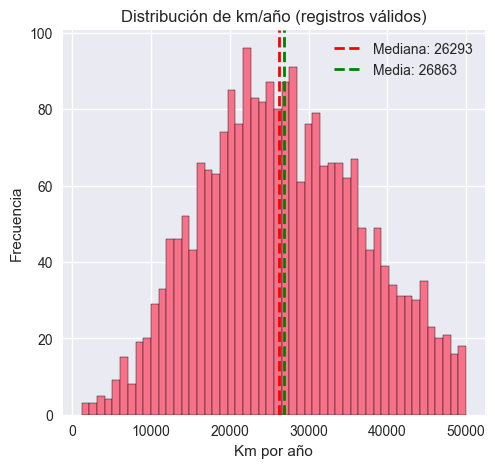

In [28]:
# Visualizamos la distribución de km/año, usaremos la mediana por ser más robusta ante outliers
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_con_fecha_limpio['km_por_año'], bins=50, edgecolor='black')
plt.axvline(km_por_año_mediana, color='red', linestyle='--', linewidth=2, label=f'Mediana: {km_por_año_mediana:.0f}')
plt.axvline(km_por_año_media, color='green', linestyle='--', linewidth=2, label=f'Media: {km_por_año_media:.0f}')
plt.xlabel('Km por año')
plt.ylabel('Frecuencia')
plt.title('Distribución de km/año (registros válidos)')
plt.legend()

In [29]:
# PASO 3: Imputamos fecha_registro para los registros SIN fecha

# Identificamos registros sin fecha_registro
df_sin_fecha_mask = df_bmw_clean['fecha_registro'].isna()
n_sin_fecha = df_sin_fecha_mask.sum()

print(f"Registros sin fecha_registro: {n_sin_fecha}")
print(f"Porcentaje: {(n_sin_fecha / len(df_bmw_clean)) * 100:.1f}%")


Registros sin fecha_registro: 2414
Porcentaje: 50.0%


In [30]:
# Para estos registros:
# 1. Estimamos EDAD_VEHICULO = km / km_por_año_mediana
# 2. Calculamos fecha_registro = fecha_venta - EDAD_VEHICULO (en días)

# Calculamos EDAD_VEHICULO estimada
edad_estimada = df_bmw_clean.loc[df_sin_fecha_mask, 'km'] / km_por_año_mediana
print(edad_estimada)

1       0.529766
3       4.869596
4       3.692921
6       7.805160
8       4.711796
          ...   
4834    1.817308
4835    6.302387
4837    2.539485
4838    1.511558
4842    7.448445
Name: km, Length: 2414, dtype: float64


In [31]:
# Actualizamos EDAD_VEHICULO
df_bmw_clean.loc[df_sin_fecha_mask, 'EDAD_VEHICULO'] = edad_estimada

# Calculamos fecha_registro: restamos EDAD_VEHICULO (en días) a fecha_venta
df_bmw_clean.loc[df_sin_fecha_mask, 'fecha_registro'] = (
    df_bmw_clean.loc[df_sin_fecha_mask, 'fecha_venta'] - 
    pd.to_timedelta(edad_estimada * 365, unit='days')
)


In [32]:
# Verificación

print(f"Nulos en fecha_registro DESPUÉS: {df_bmw_clean['fecha_registro'].isna().sum()}")
print(f"Nulos en EDAD_VEHICULO DESPUÉS: {df_bmw_clean['EDAD_VEHICULO'].isna().sum()}")
print(df_bmw_clean['EDAD_VEHICULO'].describe())


Nulos en fecha_registro DESPUÉS: 0
Nulos en EDAD_VEHICULO DESPUÉS: 0
count    4830.000000
mean        5.379602
std         2.416816
min        -5.504110
25%         4.002740
50%         5.041716
75%         6.260484
max        28.104110
Name: EDAD_VEHICULO, dtype: float64


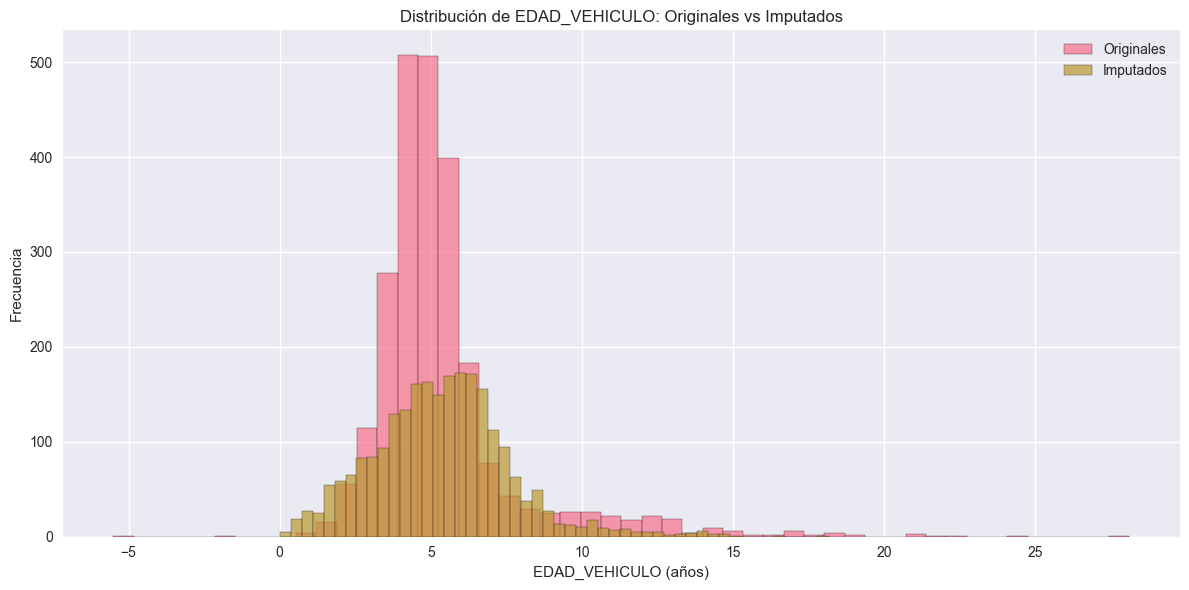

Estadísticas comparativas:
Registros ORIGINALES (con fecha_registro)
count    2416.000000
mean        5.390722
std         2.530188
min        -5.504110
25%         4.079452
50%         4.841096
75%         5.835616
max        28.104110
Name: EDAD_VEHICULO, dtype: float64
Registros IMPUTADOS (sin fecha_registro)
count    2414.000000
mean        5.368473
std         2.298228
min        -0.002434
25%         3.869928
50%         5.334819
75%         6.655526
max        18.163610
Name: EDAD_VEHICULO, dtype: float64


In [33]:
# PASO 4: Visualizamos el resultado de la imputación

# Comparamos la distribución de EDAD_VEHICULO: originales vs imputados
df_originales = df_bmw_clean[df_bmw_clean['fecha_registro_disponible'] == 1]
df_imputados = df_bmw_clean[df_bmw_clean['fecha_registro_disponible'] == 0]

# Creamos un único gráfico con ambas distribuciones superpuestas
plt.figure(figsize=(12, 6))
plt.hist(df_originales['EDAD_VEHICULO'], bins=50, alpha=0.7, label='Originales', edgecolor='black')
plt.hist(df_imputados['EDAD_VEHICULO'], bins=50, alpha=0.7, label='Imputados', edgecolor='black')
plt.xlabel('EDAD_VEHICULO (años)')
plt.ylabel('Frecuencia')
plt.title('Distribución de EDAD_VEHICULO: Originales vs Imputados')
plt.legend()
plt.tight_layout()
plt.show()

print("Estadísticas comparativas:")
print("Registros ORIGINALES (con fecha_registro)")
print(df_originales['EDAD_VEHICULO'].describe())
print("Registros IMPUTADOS (sin fecha_registro)")
print(df_imputados['EDAD_VEHICULO'].describe())


In [34]:
# Verificamos el estado final de los nulos (ACTUALIZADO)
nulos_finales = df_bmw_clean.isnull().sum()

nulos_finales = nulos_finales[nulos_finales > 0]
if len(nulos_finales) > 0:
    print(nulos_finales)
    print("A seguir con los nulos...")
else:
    print("NO HAY NULOS EN EL DATASET!")
    print("El grupo 3 lo está petando")


NO HAY NULOS EN EL DATASET!
El grupo 3 lo está petando


In [35]:
df_bmw_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4830 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   modelo                     4830 non-null   object        
 1   km                         4830 non-null   float64       
 2   potencia                   4830 non-null   float64       
 3   fecha_registro             4830 non-null   datetime64[ns]
 4   tipo_gasolina              4830 non-null   object        
 5   color                      4830 non-null   object        
 6   tipo_coche                 4830 non-null   object        
 7   volante_regulable          4830 non-null   bool          
 8   aire_acondicionado         4830 non-null   bool          
 9   camara_trasera             4830 non-null   bool          
 10  elevalunas_electrico       4830 non-null   bool          
 11  bluetooth                  4830 non-null   bool          
 12  gps        

**RESUMEN DE LA IMPUTACIÓN:**

Hemos imputado `fecha_registro` exitosamente usando la estrategia de **km/año promedio**:

1. **Calculamos** el uso promedio (km/año) de vehículos con fecha_registro conocida
2. **Limpiamos** outliers para obtener un promedio realista
3. **Estimamos** EDAD_VEHICULO para nulos: `km / km_por_año_mediana`
4. **Back-calculamos** fecha_registro: `fecha_venta - EDAD_VEHICULO`

**Ventajas de este método:**
- Usa información real del vehículo (km recorridos)
- Mantiene la relación lógica entre variables
- No requiere eliminar el 50% de los registros
- Preserva la variabilidad natural de los datos

La variable `fecha_registro_disponible` se mantiene como indicador de si el valor era original o imputado, lo cual puede ser útil para el modelo.


#### ANÁLISIS Y LIMPIEZA DE OUTLIERS


count      4830.000000
mean      15835.879917
std        9224.709002
min         100.000000
25%       10800.000000
50%       14200.000000
75%       18600.000000
max      178500.000000
Name: precio, dtype: float64


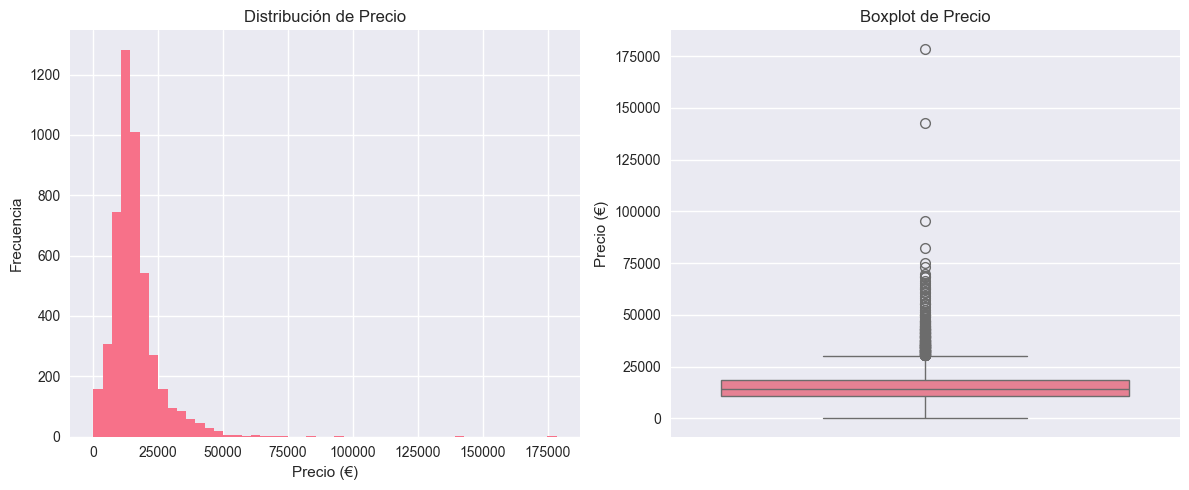

In [36]:
# Analizamos outliers en la variable target (precio)
# Los outliers pueden afectar significativamente el modelo

print(df_bmw_clean['precio'].describe())

# Visualizamos la distribución del precio CON histograma y boxplot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df_bmw_clean['precio'].hist(bins=50)
plt.title('Distribución de Precio')
plt.xlabel('Precio (€)')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_bmw_clean['precio'])
plt.title('Boxplot de Precio')
plt.ylabel('Precio (€)')

plt.tight_layout()
plt.show()


In [37]:
# Identificamos y tratamos outliers en precio usando el método IQR
# Eliminamos precios <= 0 (no tienen sentido) y valores extremos

# Eliminamos precios <= 0 (No tenemos ningun registro con precio <= 0)
# Este sería el proceso a seguir si tuvieramos registros con precio <= 0
print(f"Registros con precio <= 0: {(df_bmw_clean['precio'] <= 0).sum()}")
df_bmw_clean = df_bmw_clean[df_bmw_clean['precio'] > 0]

# Método IQR para outliers superiores
Q1 = df_bmw_clean['precio'].quantile(0.25)
Q3 = df_bmw_clean['precio'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Límites IQR:")
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")

outliers_inferiores = (df_bmw_clean['precio'] < limite_inferior).sum()
outliers_superiores = (df_bmw_clean['precio'] > limite_superior).sum()

print(f"Outliers inferiores: {outliers_inferiores}")
print(f"Outliers superiores: {outliers_superiores}")

# DECISIÓN: Para precios, los outliers superiores pueden ser válidos (coches de lujo)
# Solo eliminaríamos outliers inferiores (precios anormalmente bajos), que en nuestro caso no existen
df_bmw_clean = df_bmw_clean[df_bmw_clean['precio'] >= limite_inferior]
print(f"\nRegistros después de eliminar outliers inferiores: {len(df_bmw_clean)}")


Registros con precio <= 0: 0
Límites IQR:
Q1: 10800.00, Q3: 18600.00, IQR: 7800.00
Límite inferior: -900.00
Límite superior: 30300.00
Outliers inferiores: 0
Outliers superiores: 311

Registros después de eliminar outliers inferiores: 4830


In [38]:
# Analizamos outliers en otras variables numéricas: km, potencia, EDAD_VEHICULO

variables_numericas = ['km', 'potencia', 'EDAD_VEHICULO']

for var in variables_numericas:
    print(f"\nANÁLISIS DE {var}")
    print(df_bmw_clean[var].describe())
    
    # Eliminamos valores negativos si los hay ya que no tienen sentido
    if (df_bmw_clean[var] < 0).any():
        print(f"Valores negativos encontrados: {(df_bmw_clean[var] < 0).sum()}")
        df_bmw_clean = df_bmw_clean[df_bmw_clean[var] >= 0]
    
    # Para km y potencia, eliminamos valores extremos superiores (pueden ser errores)
    if var in ['km', 'potencia']:
        Q1 = df_bmw_clean[var].quantile(0.25)
        Q3 = df_bmw_clean[var].quantile(0.75)
        IQR = Q3 - Q1
        limite_superior = Q3 + 3 * IQR  # Usamos 3*IQR para ser menos restrictivos
        
        outliers = (df_bmw_clean[var] > limite_superior).sum()
        print(f"Outliers superiores (> Q3 + 3*IQR): {outliers}")
        
        # Solo eliminamos si hay muchos outliers (más del 1%)
        if outliers > len(df_bmw_clean) * 0.01:
            df_bmw_clean = df_bmw_clean[df_bmw_clean[var] <= limite_superior]
            print(f"Eliminados {outliers} outliers")
    
    print(f"Registros restantes: {len(df_bmw_clean)}")



ANÁLISIS DE km
count    4.830000e+03
mean     1.409558e+05
std      6.021954e+04
min     -6.400000e+01
25%      1.027825e+05
50%      1.410740e+05
75%      1.752478e+05
max      1.000376e+06
Name: km, dtype: float64
Valores negativos encontrados: 1
Outliers superiores (> Q3 + 3*IQR): 8
Registros restantes: 4829

ANÁLISIS DE potencia
count    4829.000000
mean      128.975978
std        38.998155
min         0.000000
25%       100.000000
50%       120.000000
75%       135.000000
max       423.000000
Name: potencia, dtype: float64
Outliers superiores (> Q3 + 3*IQR): 47
Registros restantes: 4829

ANÁLISIS DE EDAD_VEHICULO
count    4829.000000
mean        5.380717
std         2.415824
min        -5.504110
25%         4.002740
50%         5.042914
75%         6.261083
max        28.104110
Name: EDAD_VEHICULO, dtype: float64
Valores negativos encontrados: 2
Registros restantes: 4827


In [39]:
for var in variables_numericas:
    print(f"\nANÁLISIS DE {var}")
    print(df_bmw_clean[var].describe())


ANÁLISIS DE km
count    4.827000e+03
mean     1.409307e+05
std      6.012767e+04
min      4.760000e+02
25%      1.028070e+05
50%      1.410680e+05
75%      1.752260e+05
max      1.000376e+06
Name: km, dtype: float64

ANÁLISIS DE potencia
count    4827.000000
mean      128.983841
std        39.001001
min         0.000000
25%       100.000000
50%       120.000000
75%       135.000000
max       423.000000
Name: potencia, dtype: float64

ANÁLISIS DE EDAD_VEHICULO
count    4827.000000
mean        5.384432
std         2.409101
min         0.018104
25%         4.002740
50%         5.048809
75%         6.261083
max        28.104110
Name: EDAD_VEHICULO, dtype: float64


#### GUARDAMOS EL DATASET LIMPIO


In [40]:
# Guardamos el dataset limpio en formato pickle para uso posterior
df_bmw_clean.to_pickle("df_bmw_clean.pkl")

# Visualizamos los registros totales eliminados
print(f"Dataset guardado. Dimensiones finales: {df_bmw_clean.shape}")
print(f"Registros originales: {df_bmw.shape[0]}")
print(f"Registros finales: {df_bmw_clean.shape[0]}")
print(f"Registros eliminados: {df_bmw.shape[0] - df_bmw_clean.shape[0]}")


Dataset guardado. Dimensiones finales: (4827, 18)
Registros originales: 4843
Registros finales: 4827
Registros eliminados: 16



---

# PARTE 2: EDA

---


### PARTE 2: ANÁLISIS EXPLORATORIO DE DATOS (EDA)


#### LEEMOS EL DATASET LIMPIO


In [41]:
# Leemos el dataset limpio
df_bmw_clean = pd.read_pickle("df_bmw_clean.pkl")
df_bmw_clean.head()


,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta,EDAD_VEHICULO,fecha_registro_disponible
0,118,140411.0,100.0,2012-02-01 00:00:00.000000000,diesel,black,desconocido,True,True,False,True,False,True,False,11300.0,2018-01-01,5.920548,1
1,M4,13929.0,317.0,2017-07-22 15:14:56.469719357,petrol,grey,convertible,True,True,False,False,True,True,True,69700.0,2018-02-01,0.529766,0
2,320,183297.0,120.0,2012-04-01 00:00:00.000000000,diesel,white,desconocido,False,False,False,True,False,True,False,10200.0,2018-02-01,5.841096,1
3,420,128035.0,135.0,2013-03-21 14:20:22.535754049,diesel,red,convertible,True,True,False,True,True,True,False,25100.0,2018-02-01,4.869596,0
4,425,97097.0,160.0,2014-07-23 02:00:39.293584658,diesel,silver,desconocido,True,True,False,False,True,True,True,33400.0,2018-04-01,3.692921,0


#### PREGUNTA 3: ANÁLISIS UNIVARIABLE

Analizamos cada variable individualmente para entender su distribución y encontrar información interesante.



ANÁLISIS DE KM
count    4.827000e+03
mean     1.409307e+05
std      6.012767e+04
min      4.760000e+02
25%      1.028070e+05
50%      1.410680e+05
75%      1.752260e+05
max      1.000376e+06
Name: km, dtype: float64


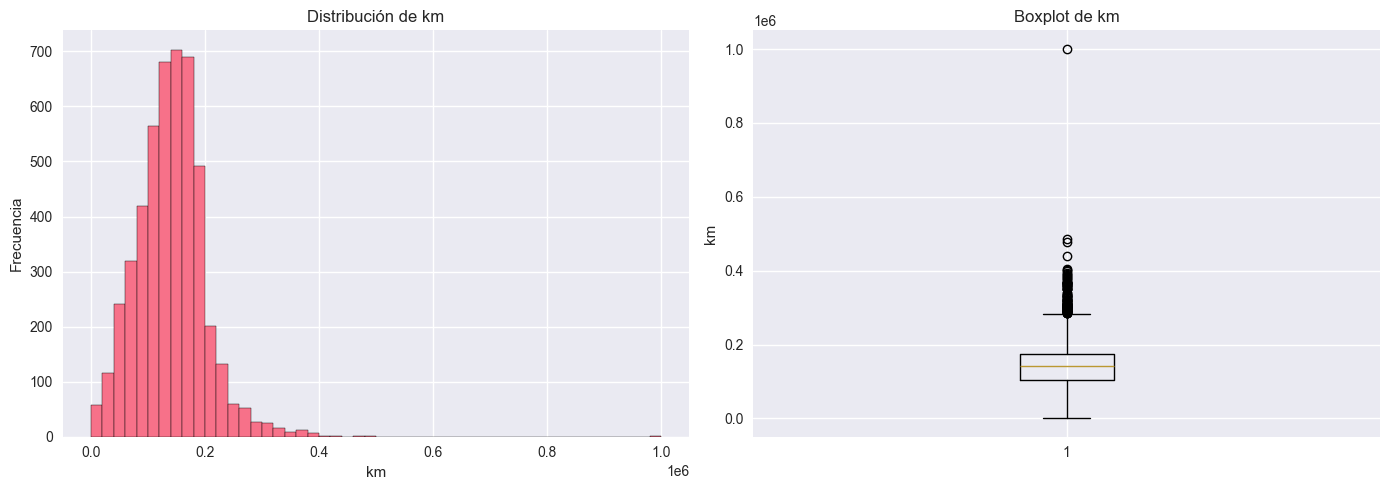


INSIGHT: Los coches tienen en promedio 140931 km
   El rango va desde 476 hasta 1000376 km

ANÁLISIS DE POTENCIA
count    4827.000000
mean      128.983841
std        39.001001
min         0.000000
25%       100.000000
50%       120.000000
75%       135.000000
max       423.000000
Name: potencia, dtype: float64


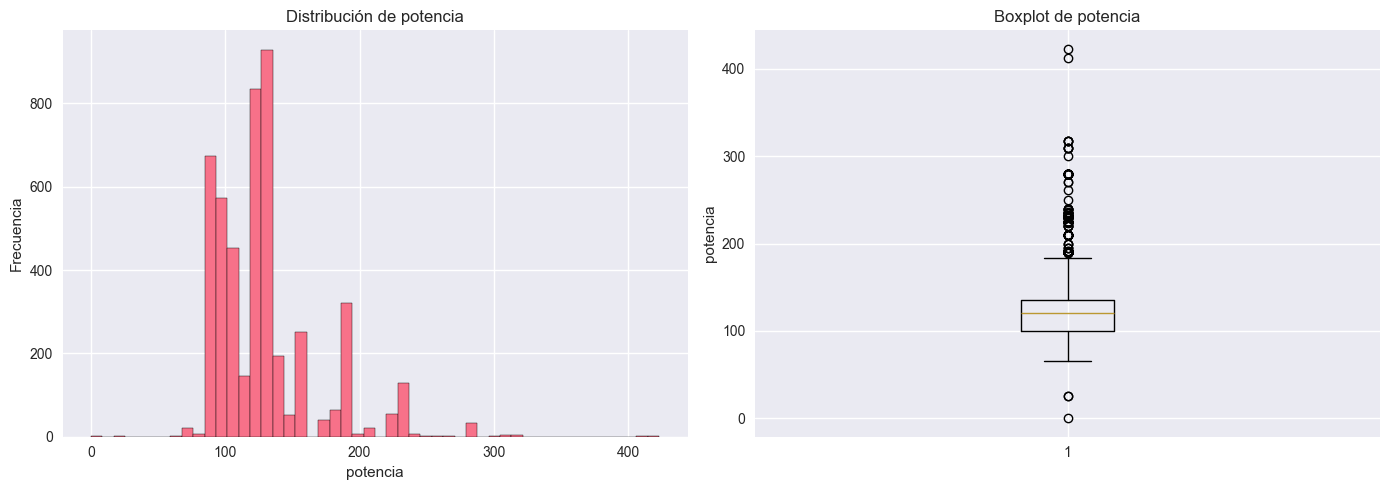


INSIGHT: La potencia media es 129.0 CV
   Potencia mínima: 0 CV, máxima: 423 CV

ANÁLISIS DE PRECIO
count      4827.000000
mean      15826.662523
std        9186.969575
min         100.000000
25%       10850.000000
50%       14200.000000
75%       18600.000000
max      178500.000000
Name: precio, dtype: float64


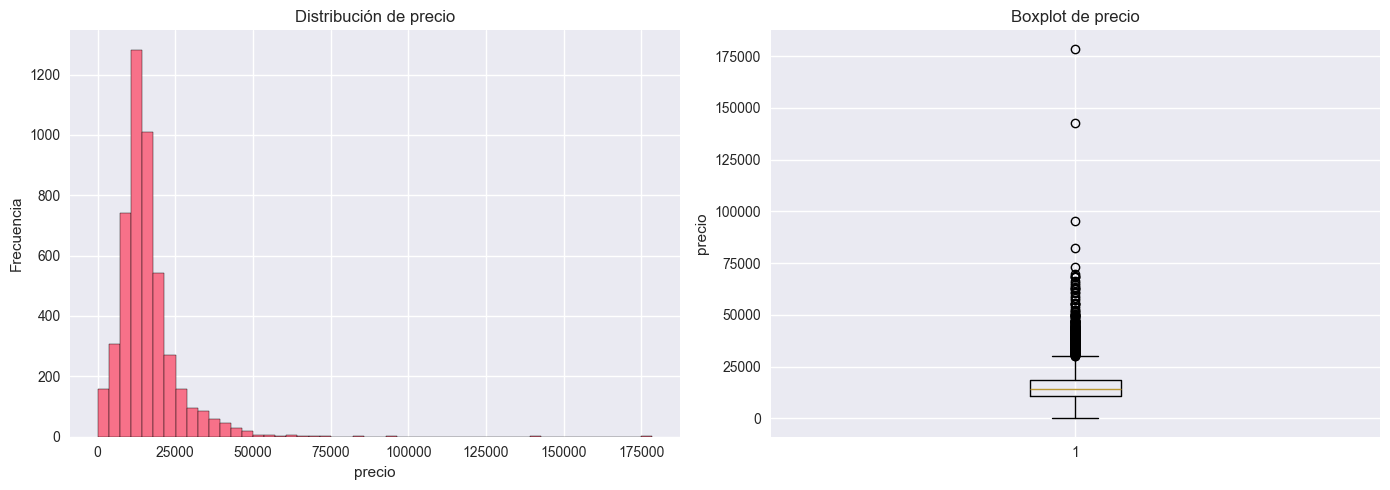


INSIGHT: El precio medio es 15826.66€
   El precio mediano es 14200.00€

ANÁLISIS DE EDAD_VEHICULO
count    4827.000000
mean        5.384432
std         2.409101
min         0.018104
25%         4.002740
50%         5.048809
75%         6.261083
max        28.104110
Name: EDAD_VEHICULO, dtype: float64


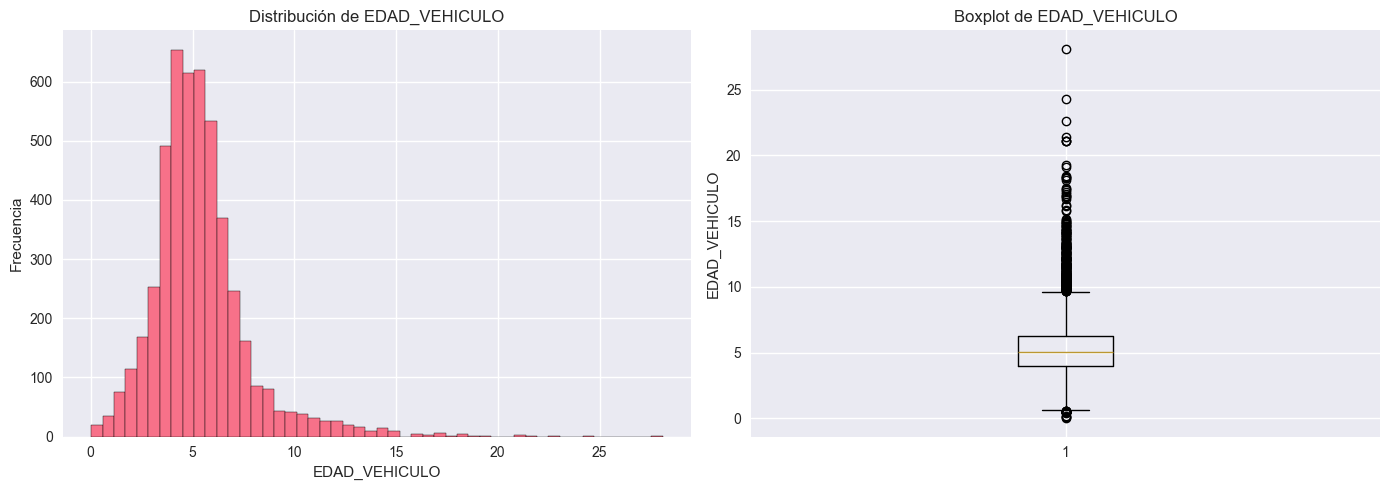

In [43]:
# ANÁLISIS DE VARIABLES NUMÉRICAS

variables_numericas = ['km', 'potencia', 'precio', 'EDAD_VEHICULO']

for var in variables_numericas:
    print(f"\n{'='*50}")
    print(f"ANÁLISIS DE {var.upper()}")
    print(f"{'='*50}")
    print(df_bmw_clean[var].describe())
    
    # Visualizaciones
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histograma
    axes[0].hist(df_bmw_clean[var].dropna(), bins=50, edgecolor='black')
    axes[0].set_title(f'Distribución de {var}')
    axes[0].set_xlabel(var)
    axes[0].set_ylabel('Frecuencia')
    
    # Boxplot
    axes[1].boxplot(df_bmw_clean[var].dropna())
    axes[1].set_title(f'Boxplot de {var}')
    axes[1].set_ylabel(var)
    
    plt.tight_layout()
    plt.show()
    
    # Información interesante
    if var == 'precio':
        print(f"\nINSIGHT: El precio medio es {df_bmw_clean[var].mean():.2f}€")
        print(f"   El precio mediano es {df_bmw_clean[var].median():.2f}€")
    elif var == 'km':
        print(f"\nINSIGHT: Los coches tienen en promedio {df_bmw_clean[var].mean():.0f} km")
        print(f"   El rango va desde {df_bmw_clean[var].min():.0f} hasta {df_bmw_clean[var].max():.0f} km")
    elif var == 'potencia':
        print(f"\nINSIGHT: La potencia media es {df_bmw_clean[var].mean():.1f} CV")
        print(f"   Potencia mínima: {df_bmw_clean[var].min():.0f} CV, máxima: {df_bmw_clean[var].max():.0f} CV")



ANÁLISIS DE MODELO

Top 10 valores más frecuentes:
modelo
320    749
520    631
318    567
X3     437
116    358
X1     274
316    233
X5     231
525    182
530    157
Name: count, dtype: int64

Número de categorías únicas: 76
Porcentaje del valor más frecuente: 15.52%


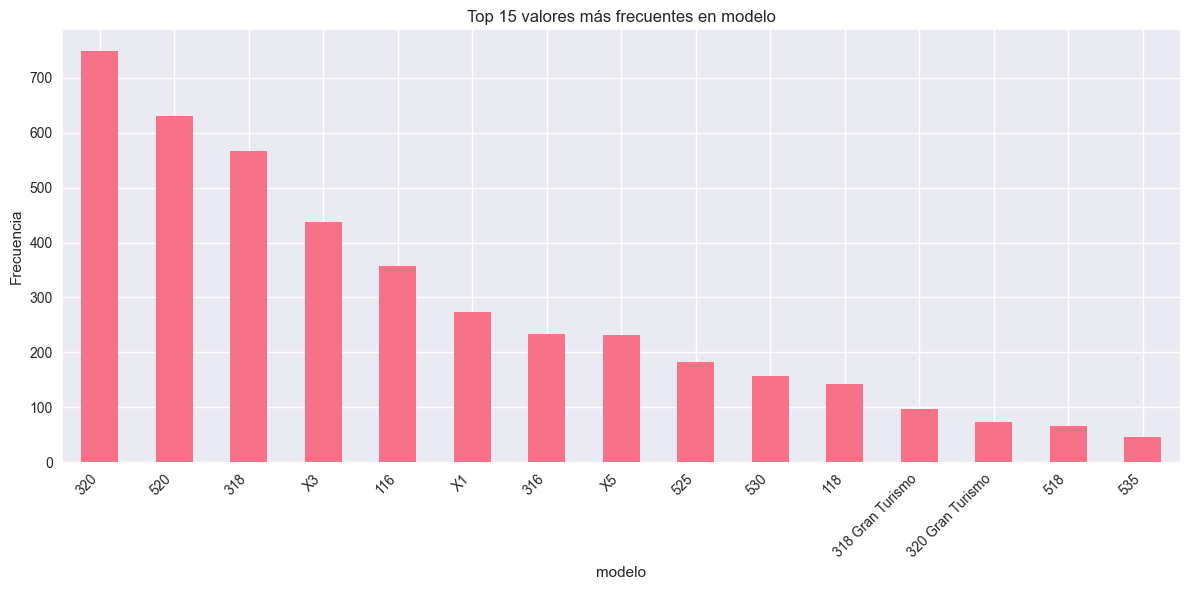


INSIGHT: El modelo más común es '320' con 749 unidades

ANÁLISIS DE TIPO_GASOLINA

Top 10 valores más frecuentes:
tipo_gasolina
diesel           4620
petrol            191
hybrid_petrol       8
Diesel              5
electro             3
Name: count, dtype: int64

Número de categorías únicas: 5
Porcentaje del valor más frecuente: 95.71%


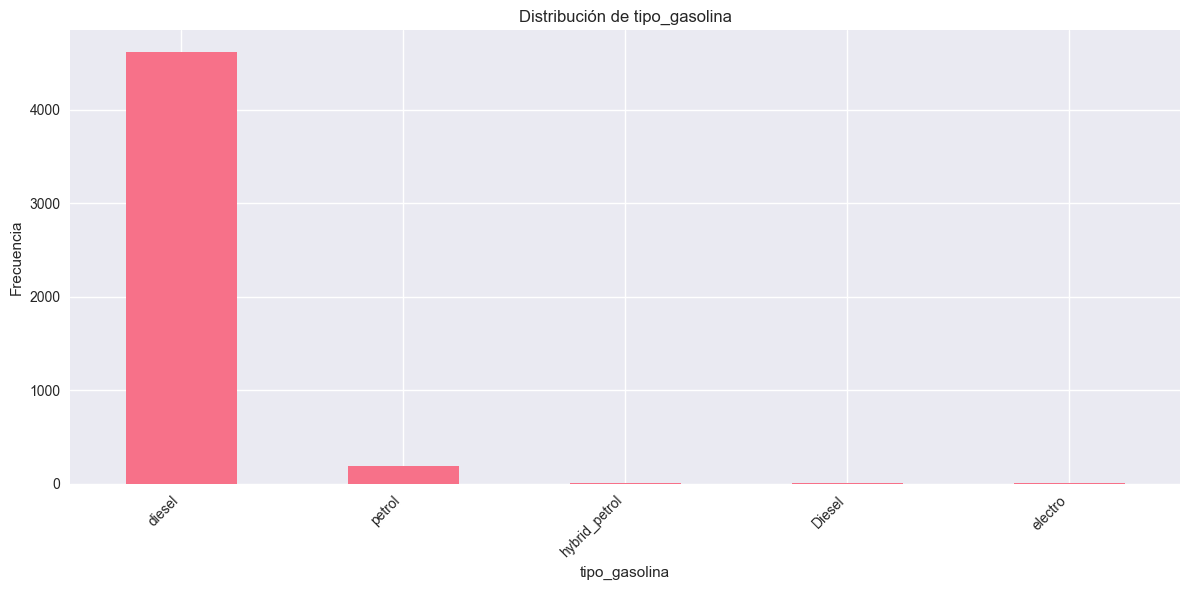


INSIGHT: diesel es el tipo de combustible más común
   Distribución: {'diesel': np.int64(4620), 'petrol': np.int64(191), 'hybrid_petrol': np.int64(8), 'Diesel': np.int64(5), 'electro': np.int64(3)}

ANÁLISIS DE COLOR

Top 10 valores más frecuentes:
color
black          1492
grey           1069
blue            643
white           483
desconocido     444
brown           302
silver          290
red              47
beige            37
green            14
Name: count, dtype: int64

Número de categorías únicas: 11
Porcentaje del valor más frecuente: 30.91%


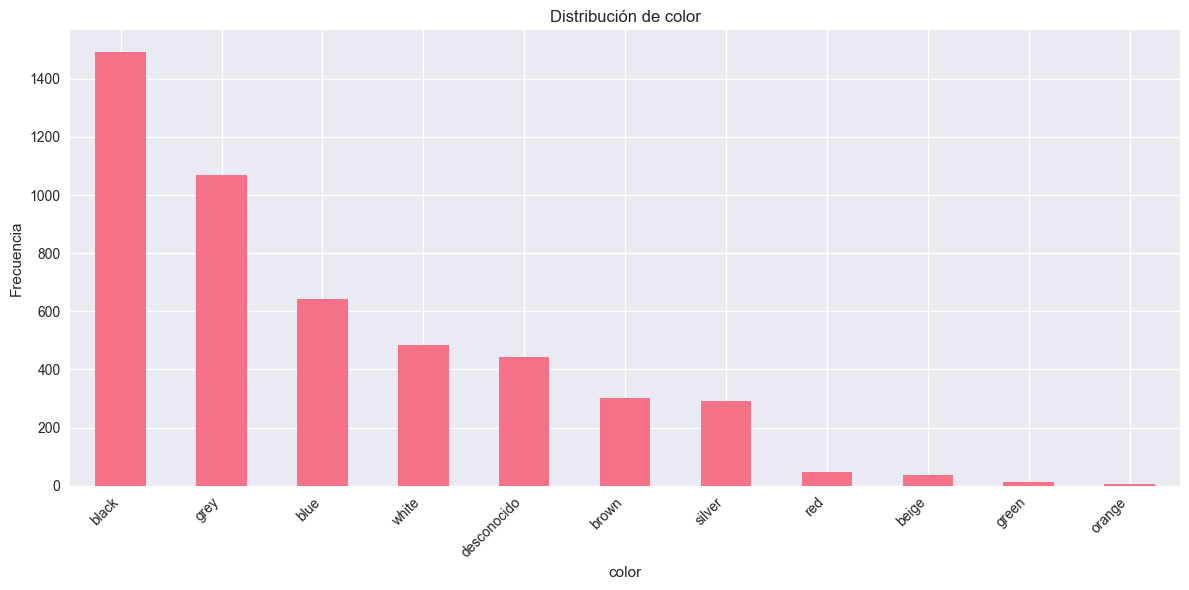


INSIGHT: El color más popular es 'black'

ANÁLISIS DE TIPO_COCHE

Top 10 valores más frecuentes:
tipo_coche
desconocido    1453
estate         1102
sedan           820
suv             754
hatchback       488
subcompact       77
coupe            75
convertible      30
van              28
Name: count, dtype: int64

Número de categorías únicas: 9
Porcentaje del valor más frecuente: 30.10%


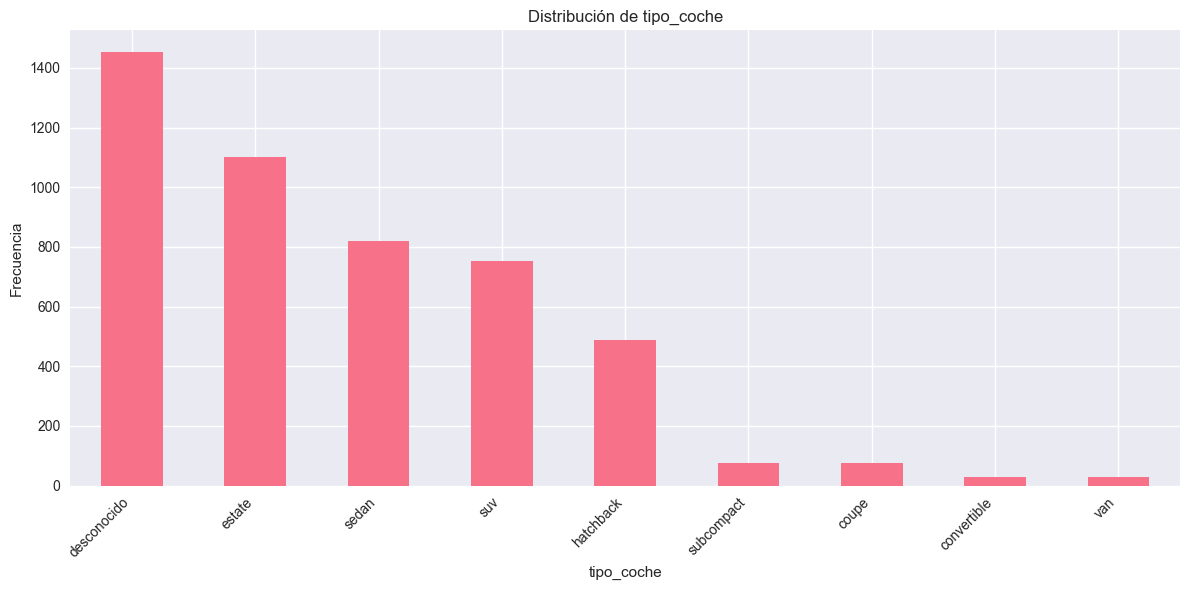

In [44]:
# ANÁLISIS DE VARIABLES CATEGÓRICAS

variables_categoricas = ['modelo', 'tipo_gasolina', 'color', 'tipo_coche']

for var in variables_categoricas:
    print(f"\n{'='*50}")
    print(f"ANÁLISIS DE {var.upper()}")
    print(f"{'='*50}")
    
    value_counts = df_bmw_clean[var].value_counts()
    print(f"\nTop 10 valores más frecuentes:")
    print(value_counts.head(10))
    
    print(f"\nNúmero de categorías únicas: {df_bmw_clean[var].nunique()}")
    print(f"Porcentaje del valor más frecuente: {(value_counts.iloc[0] / len(df_bmw_clean)) * 100:.2f}%")
    
    # Visualización
    plt.figure(figsize=(12, 6))
    if df_bmw_clean[var].nunique() > 20:
        # Si hay muchas categorías, mostramos solo las top 15
        top_values = value_counts.head(15)
        top_values.plot(kind='bar')
        plt.title(f'Top 15 valores más frecuentes en {var}')
    else:
        value_counts.plot(kind='bar')
        plt.title(f'Distribución de {var}')
    
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    # Insights
    if var == 'modelo':
        print(f"\nINSIGHT: El modelo más común es '{value_counts.index[0]}' con {value_counts.iloc[0]} unidades")
    elif var == 'tipo_gasolina':
        print(f"\nINSIGHT: {value_counts.index[0]} es el tipo de combustible más común")
        print(f"   Distribución: {dict(value_counts)}")
    elif var == 'color':
        print(f"\nINSIGHT: El color más popular es '{value_counts.index[0]}'")


Distribución de variables booleanas:

volante_regulable:
  True: 2653 (55.0%)
  False: 2174 (45.0%)

aire_acondicionado:
  True: 3454 (71.6%)
  False: 1373 (28.4%)

camara_trasera:
  True: 971 (20.1%)
  False: 3856 (79.9%)

elevalunas_electrico:
  True: 2222 (46.0%)
  False: 2605 (54.0%)

bluetooth:
  True: 993 (20.6%)
  False: 3834 (79.4%)

gps:
  True: 4499 (93.2%)
  False: 328 (6.8%)

alerta_lim_velocidad:
  True: 2232 (46.2%)
  False: 2595 (53.8%)


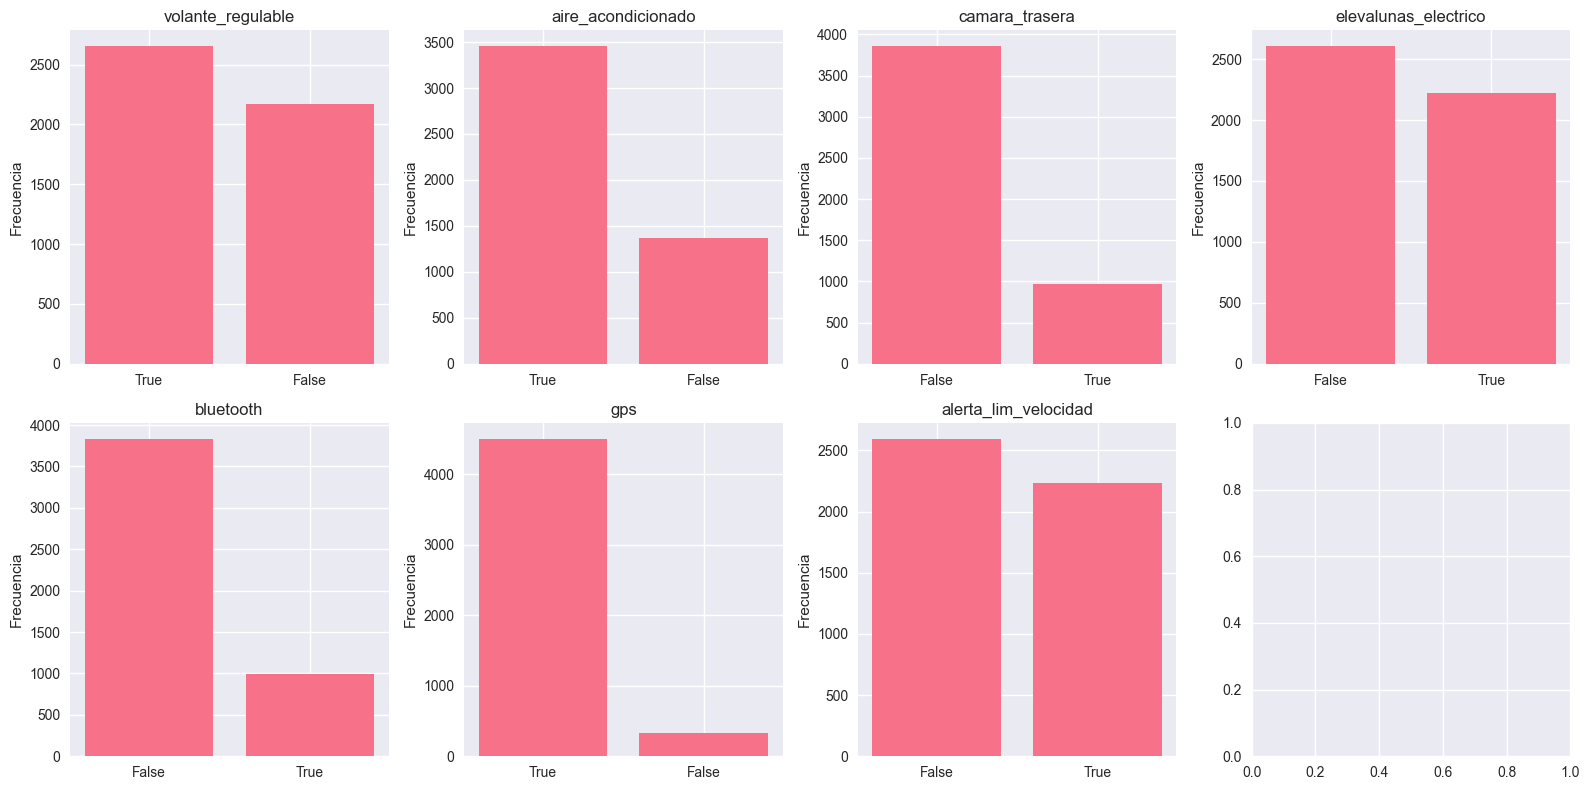

In [45]:
# ANÁLISIS DE VARIABLES BOOLEANAS

variables_booleanas = ['volante_regulable', 'aire_acondicionado', 'camara_trasera', 
                       'elevalunas_electrico', 'bluetooth', 'gps', 'alerta_lim_velocidad']

print("Distribución de variables booleanas:")
print("="*60)

for var in variables_booleanas:
    value_counts = df_bmw_clean[var].value_counts()
    porcentaje_true = (value_counts.get(True, 0) / len(df_bmw_clean)) * 100
    print(f"\n{var}:")
    print(f"  True: {value_counts.get(True, 0)} ({porcentaje_true:.1f}%)")
    print(f"  False: {value_counts.get(False, 0)} ({100-porcentaje_true:.1f}%)")

# Visualización
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, var in enumerate(variables_booleanas):
    value_counts = df_bmw_clean[var].value_counts()
    axes[i].bar(value_counts.index.astype(str), value_counts.values)
    axes[i].set_title(var)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


#### PREGUNTA 4: ANÁLISIS DE CORRELACIÓN INICIAL

Identificamos variables correlacionadas que podrían causar multicolinealidad en el modelo.


Matriz de correlación (variables numéricas):
                                 km  potencia    precio  EDAD_VEHICULO  \
km                         1.000000 -0.049298 -0.408837       0.730443   
potencia                  -0.049298  1.000000  0.639132      -0.080243   
precio                    -0.408837  0.639132  1.000000      -0.422825   
EDAD_VEHICULO              0.730443 -0.080243 -0.422825       1.000000   
fecha_registro_disponible -0.004650  0.014375  0.019591       0.005700   

                           fecha_registro_disponible  
km                                         -0.004650  
potencia                                    0.014375  
precio                                      0.019591  
EDAD_VEHICULO                               0.005700  
fecha_registro_disponible                   1.000000  


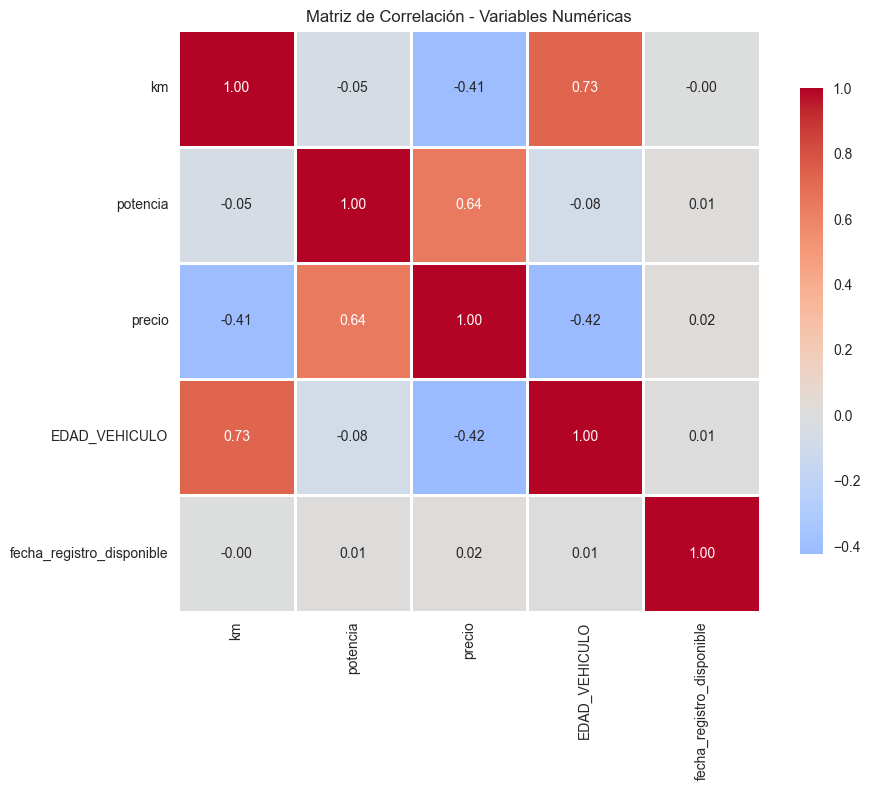

In [46]:
# Calculamos la matriz de correlación solo para variables numéricas
# La correlación mide la relación lineal entre variables

variables_numericas_corr = ['km', 'potencia', 'precio', 'EDAD_VEHICULO', 'fecha_registro_disponible']
corr = df_bmw_clean[variables_numericas_corr].corr()

print("Matriz de correlación (variables numéricas):")
print(corr)

# Visualización con mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Matriz de Correlación - Variables Numéricas')
plt.tight_layout()
plt.show()


In [47]:
# Identificamos pares de variables con alta correlación (|r| > 0.7)
# Estas variables pueden causar multicolinealidad

print("Pares de variables con correlación alta (|r| > 0.7):")
print("="*60)

# Obtenemos el triángulo superior de la matriz (sin la diagonal)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
corr_triangulo = corr.where(mask)

# Buscamos correlaciones altas
for i in range(len(corr_triangulo.columns)):
    for j in range(i+1, len(corr_triangulo.columns)):
        valor = corr_triangulo.iloc[i, j]
        if not np.isnan(valor) and abs(valor) > 0.7:
            var1 = corr_triangulo.columns[i]
            var2 = corr_triangulo.columns[j]
            print(f"{var1} - {var2}: {valor:.3f}")

# Si no hay correlaciones altas
if corr_triangulo.abs().max().max() <= 0.7:
    print("No se encontraron correlaciones altas (|r| > 0.7) entre variables numéricas")
    print(f"Correlación máxima: {corr_triangulo.abs().max().max():.3f}")


Pares de variables con correlación alta (|r| > 0.7):
km - EDAD_VEHICULO: 0.730


#### PREGUNTA 5: ANÁLISIS VARIABLE VS TARGET

Analizamos la relación entre cada variable y el precio (target) para identificar insights interesantes.



ANÁLISIS: KM vs PRECIO
Correlación con precio: -0.409


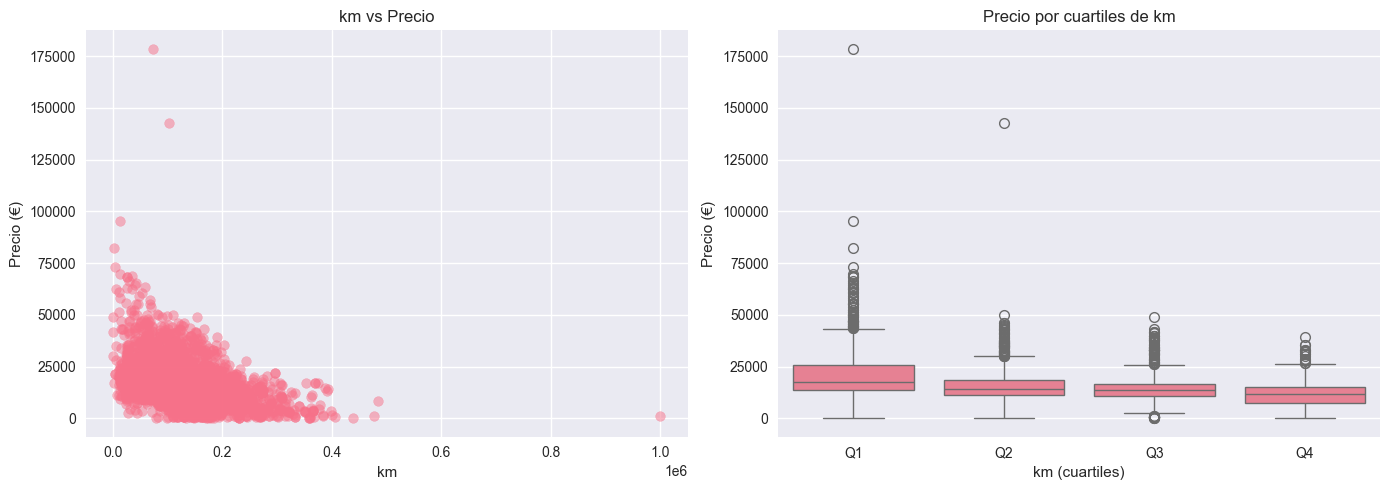


INSIGHT: Correlación negativa moderada/alta (-0.409)
   A mayor kilometraje, menor precio (correlación negativa esperada)

ANÁLISIS: POTENCIA vs PRECIO
Correlación con precio: 0.639


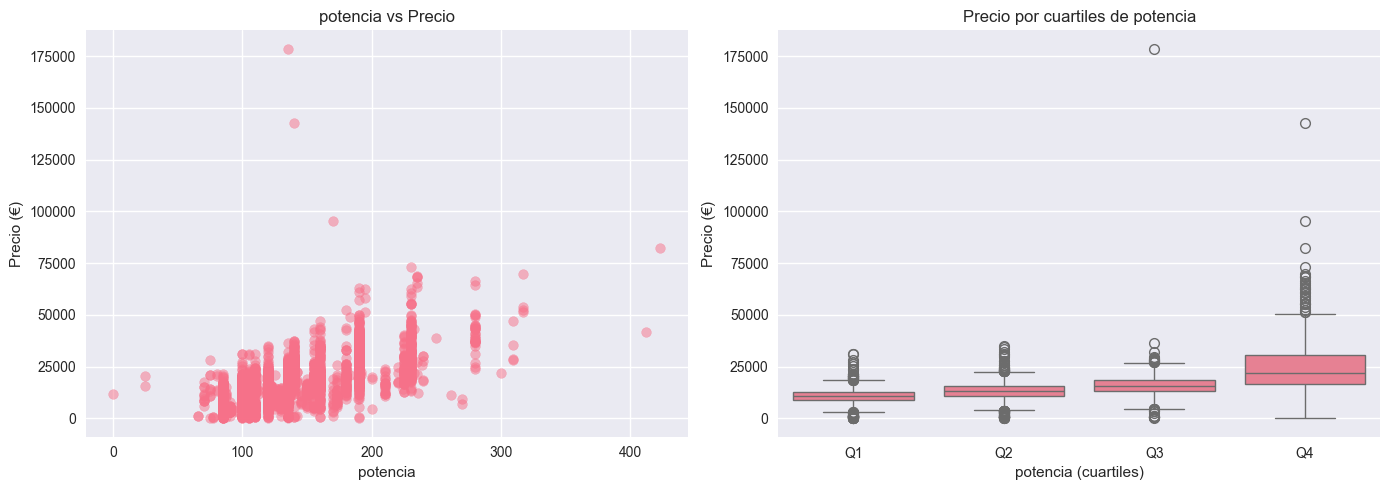


INSIGHT: Correlación positiva moderada/alta (0.639)
   A mayor potencia, mayor precio (correlación positiva esperada)

ANÁLISIS: EDAD_VEHICULO vs PRECIO
Correlación con precio: -0.423


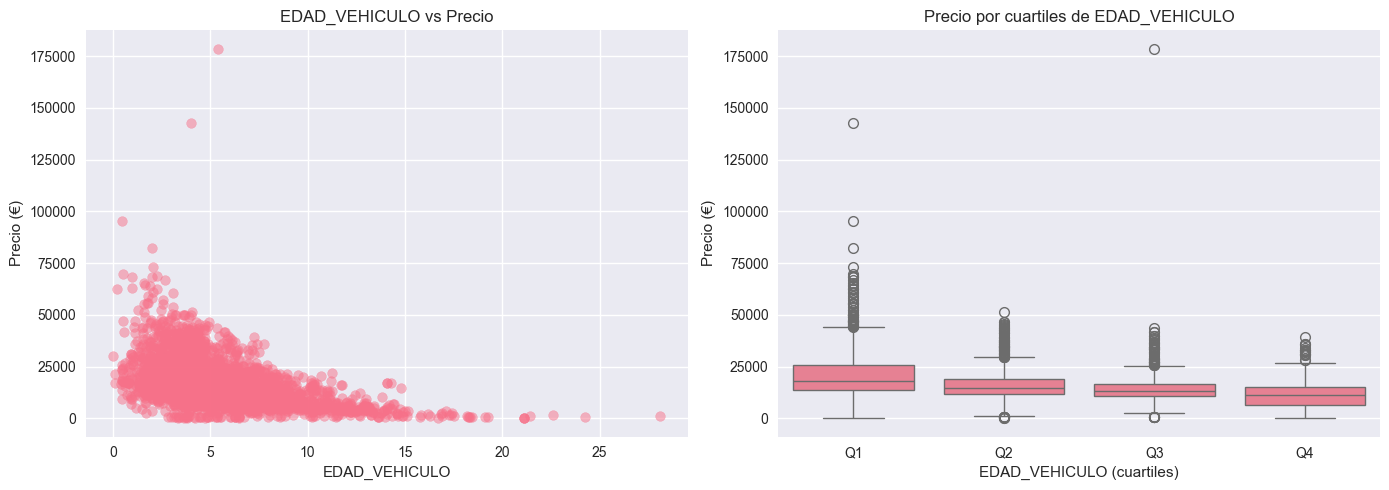


INSIGHT: Correlación negativa moderada/alta (-0.423)


In [49]:
# ANÁLISIS: Variables numéricas vs Precio

variables_numericas_vs_target = ['km', 'potencia', 'EDAD_VEHICULO']

for var in variables_numericas_vs_target:
    print(f"\n{'='*50}")
    print(f"ANÁLISIS: {var.upper()} vs PRECIO")
    print(f"{'='*50}")
    
    # Correlación
    correlacion = df_bmw_clean[var].corr(df_bmw_clean['precio'])
    print(f"Correlación con precio: {correlacion:.3f}")
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter plot
    axes[0].scatter(df_bmw_clean[var], df_bmw_clean['precio'], alpha=0.5)
    axes[0].set_xlabel(var)
    axes[0].set_ylabel('Precio (€)')
    axes[0].set_title(f'{var} vs Precio')
    
    # Boxplot por cuartiles
    df_bmw_clean[f'{var}_quartile'] = pd.qcut(df_bmw_clean[var], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')
    sns.boxplot(data=df_bmw_clean, x=f'{var}_quartile', y='precio', ax=axes[1])
    axes[1].set_title(f'Precio por cuartiles de {var}')
    axes[1].set_xlabel(f'{var} (cuartiles)')
    axes[1].set_ylabel('Precio (€)')
    
    plt.tight_layout()
    plt.show()
    
    # Eliminamos la columna temporal
    df_bmw_clean.drop(columns=[f'{var}_quartile'], inplace=True)
    
    # Insight
    if abs(correlacion) > 0.3:
        direccion = "positiva" if correlacion > 0 else "negativa"
        print(f"\nINSIGHT: Correlación {direccion} moderada/alta ({correlacion:.3f})")
        if var == 'km':
            print("   A mayor kilometraje, menor precio (correlación negativa esperada)")
        elif var == 'potencia':
            print("   A mayor potencia, mayor precio (correlación positiva esperada)")
    else:
        print(f"\nINSIGHT: Correlación débil con precio ({correlacion:.3f})")



ANÁLISIS: MODELO vs PRECIO

Precio medio por categoría (top 10):
                        mean   median  count
modelo                                      
i8              95200.000000  95200.0      1
M4              61650.000000  61650.0      2
X6 M            51050.000000  45800.0      8
X5 M50          49533.333333  49900.0      3
M5              41600.000000  41600.0      1
X5 M            37788.235294  40900.0     17
740             37772.222222  30950.0     18
750             37200.000000  37200.0      2
640 Gran Coupé  37066.666667  35150.0     18
M3              36428.571429  35700.0      7


/var/folders/5l/r6fc5n5s5k1dsgmfjbxysbxr0000gn/T/ipykernel_5959/2528085273.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')


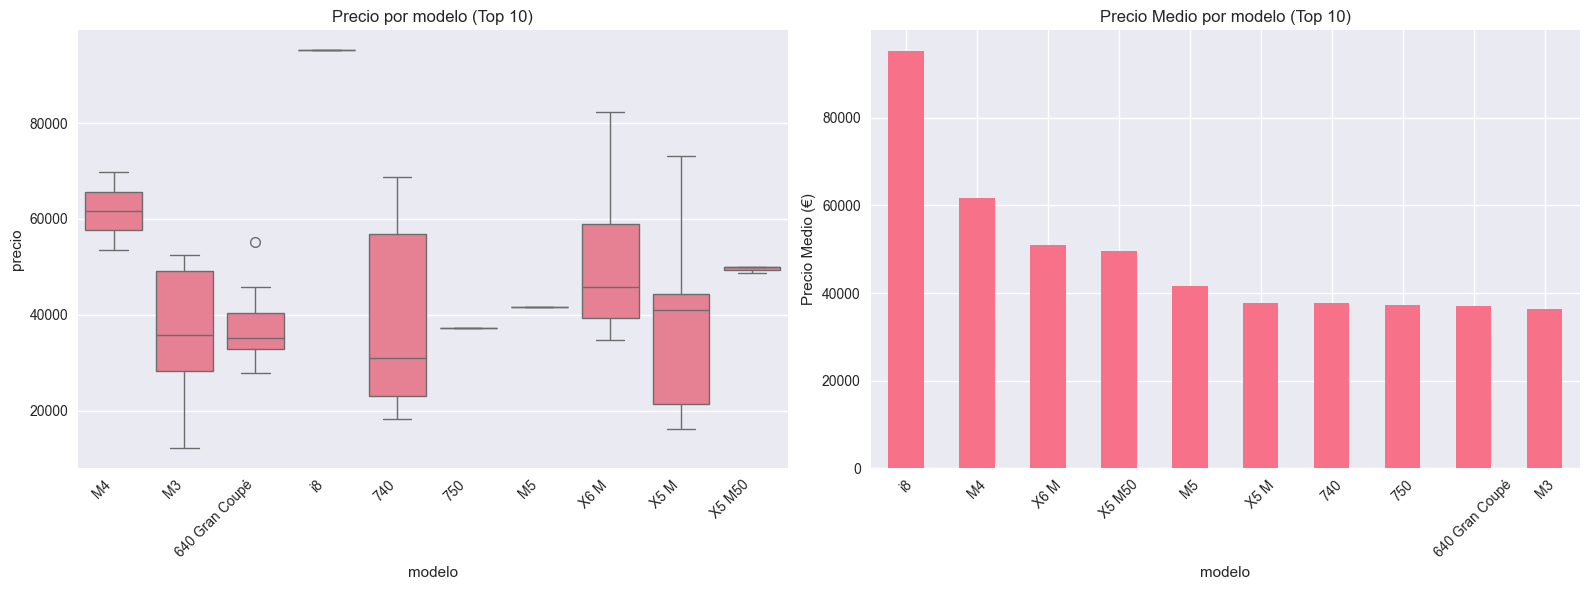


INSIGHT:
   Categoría más cara: i8 (precio medio: 95200.00€)
   Categoría más barata: 735 (precio medio: 4500.00€)
   Diferencia: 90700.00€

ANÁLISIS: TIPO_GASOLINA vs PRECIO

Precio medio por categoría (top 10):
                       mean   median  count
tipo_gasolina                              
hybrid_petrol  37575.000000  25000.0      8
electro        20966.666667  20900.0      3
diesel         15846.731602  14300.0   4620
petrol         14398.429319  11900.0    191
Diesel         13960.000000  12700.0      5


/var/folders/5l/r6fc5n5s5k1dsgmfjbxysbxr0000gn/T/ipykernel_5959/2528085273.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')


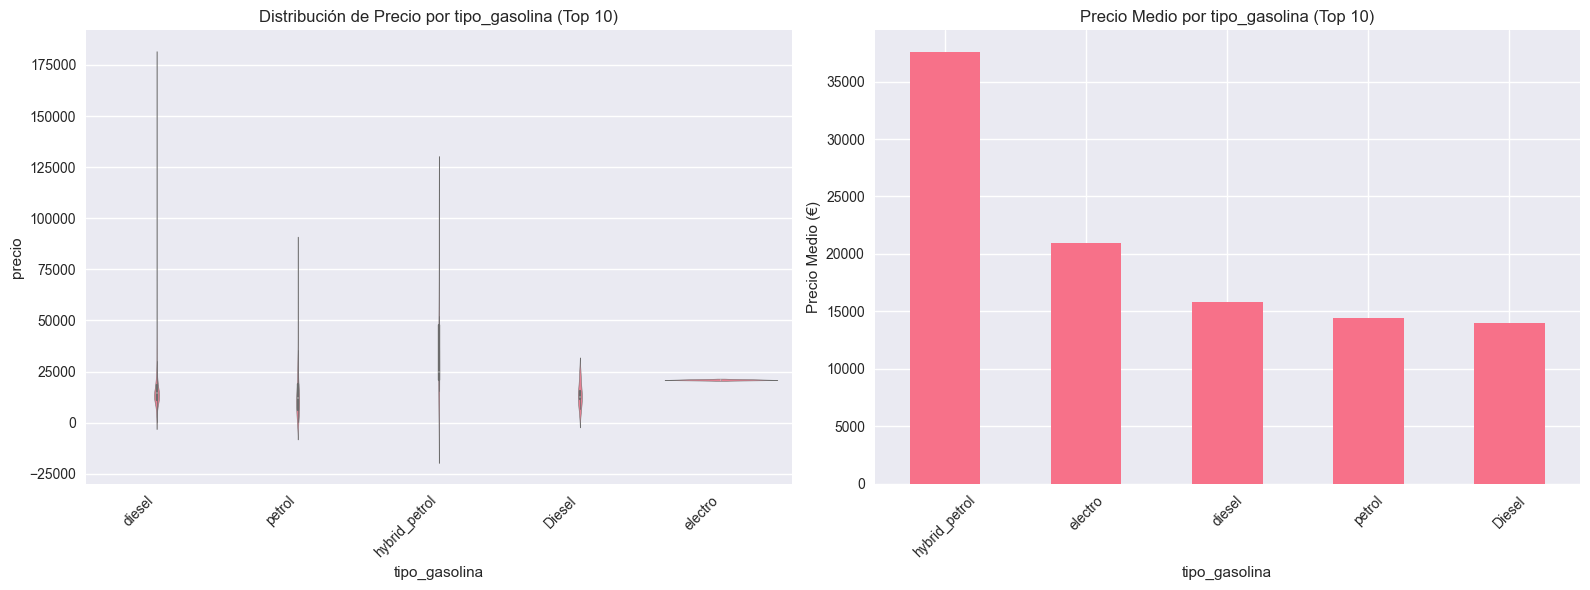


INSIGHT:
   Categoría más cara: hybrid_petrol (precio medio: 37575.00€)
   Categoría más barata: Diesel (precio medio: 13960.00€)
   Diferencia: 23615.00€

ANÁLISIS: COLOR vs PRECIO

Precio medio por categoría (top 10):
                     mean   median  count
color                                    
orange       18866.666667  17400.0      6
white        17282.194617  14900.0    483
red          16642.553191  13400.0     47
black        16166.487936  14550.0   1492
grey         15613.844715  14000.0   1069
brown        15545.695364  13900.0    302
desconocido  15526.576577  13750.0    444
blue         15226.127527  13400.0    643
beige        14916.216216  13600.0     37
silver       14872.413793  14250.0    290


/var/folders/5l/r6fc5n5s5k1dsgmfjbxysbxr0000gn/T/ipykernel_5959/2528085273.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')


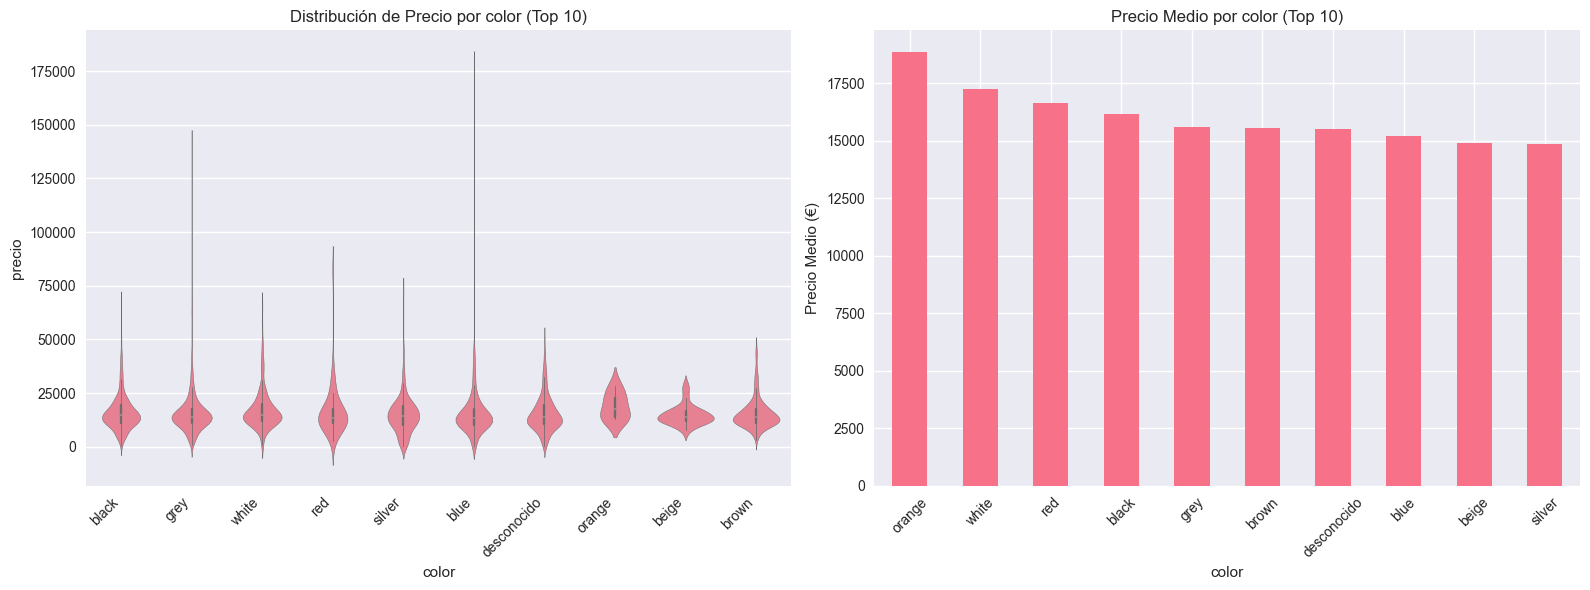


INSIGHT:
   Categoría más cara: orange (precio medio: 18866.67€)
   Categoría más barata: green (precio medio: 6935.71€)
   Diferencia: 11930.95€

ANÁLISIS: TIPO_COCHE vs PRECIO

Precio medio por categoría (top 10):
                     mean   median  count
tipo_coche                               
coupe        22518.666667  23100.0     75
suv          21753.846154  17800.0    754
convertible  16796.666667  12100.0     30
sedan        16015.000000  14900.0    820
desconocido  15587.061253  14200.0   1453
van          14646.428571  14100.0     28
hatchback    13275.819672  11900.0    488
estate       13050.544465  12950.0   1102
subcompact    9732.467532   9300.0     77


/var/folders/5l/r6fc5n5s5k1dsgmfjbxysbxr0000gn/T/ipykernel_5959/2528085273.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')


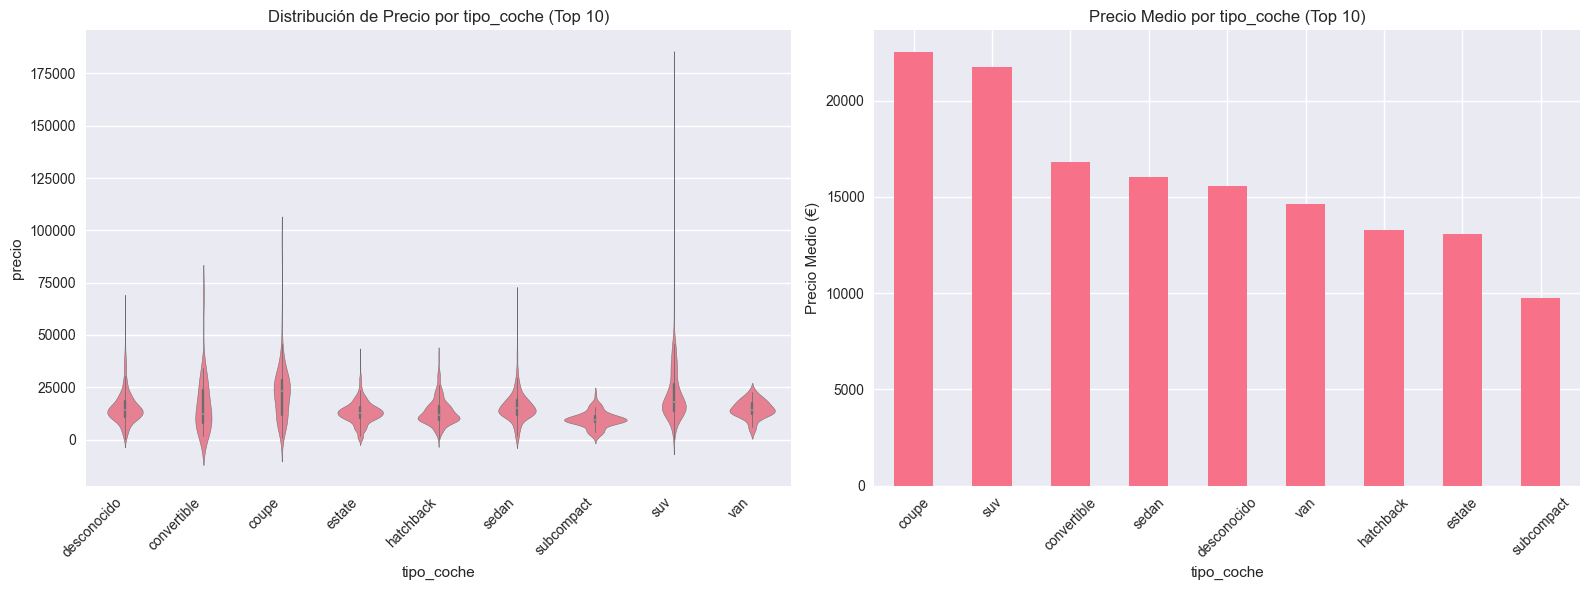


INSIGHT:
   Categoría más cara: coupe (precio medio: 22518.67€)
   Categoría más barata: subcompact (precio medio: 9732.47€)
   Diferencia: 12786.20€


In [51]:
# ANÁLISIS: Variables categóricas vs Precio

variables_categoricas_vs_target = ['modelo', 'tipo_gasolina', 'color', 'tipo_coche']

for var in variables_categoricas_vs_target:
    print(f"\n{'='*50}")
    print(f"ANÁLISIS: {var.upper()} vs PRECIO")
    print(f"{'='*50}")
    
    # Estadísticas por categoría
    stats_por_categoria = df_bmw_clean.groupby(var)['precio'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
    print(f"\nPrecio medio por categoría (top 10):")
    print(stats_por_categoria.head(10))
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Violin plot (si hay pocas categorías) o boxplot
    if df_bmw_clean[var].nunique() <= 15:
        # Violin plot para ver distribución
        top_categorias = stats_por_categoria.head(10).index
        df_top = df_bmw_clean[df_bmw_clean[var].isin(top_categorias)]
        sns.violinplot(data=df_top, x=var, y='precio', ax=axes[0])
        axes[0].set_title(f'Distribución de Precio por {var} (Top 10)')
        axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
    else:
        # Boxplot para muchas categorías
        top_categorias = stats_por_categoria.head(10).index
        df_top = df_bmw_clean[df_bmw_clean[var].isin(top_categorias)]
        sns.boxplot(data=df_top, x=var, y='precio', ax=axes[0])
        axes[0].set_title(f'Precio por {var} (Top 10)')
        axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
    
    # Precio medio por categoría
    top_10_mean = stats_por_categoria.head(10)
    top_10_mean['mean'].plot(kind='bar', ax=axes[1])
    axes[1].set_title(f'Precio Medio por {var} (Top 10)')
    axes[1].set_xlabel(var)
    axes[1].set_ylabel('Precio Medio (€)')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Insight
    categoria_mas_cara = stats_por_categoria.index[0]
    categoria_mas_barata = stats_por_categoria.index[-1]
    diferencia = stats_por_categoria.loc[categoria_mas_cara, 'mean'] - stats_por_categoria.loc[categoria_mas_barata, 'mean']
    
    print(f"\nINSIGHT:")
    print(f"   Categoría más cara: {categoria_mas_cara} (precio medio: {stats_por_categoria.loc[categoria_mas_cara, 'mean']:.2f}€)")
    print(f"   Categoría más barata: {categoria_mas_barata} (precio medio: {stats_por_categoria.loc[categoria_mas_barata, 'mean']:.2f}€)")
    print(f"   Diferencia: {diferencia:.2f}€")


Impacto de características booleanas en el precio:

volante_regulable:
  Con volante_regulable: 18065.13€ (n=2653)
  Sin volante_regulable: 13094.99€ (n=2174)
  Diferencia: +4970.15€ (+38.0%)

aire_acondicionado:
  Con aire_acondicionado: 17035.32€ (n=3454)
  Sin aire_acondicionado: 12786.09€ (n=1373)
  Diferencia: +4249.23€ (+33.2%)

camara_trasera:
  Con camara_trasera: 20471.58€ (n=971)
  Sin camara_trasera: 14657.00€ (n=3856)
  Diferencia: +5814.57€ (+39.7%)

elevalunas_electrico:
  Con elevalunas_electrico: 18440.19€ (n=2222)
  Sin elevalunas_electrico: 13597.39€ (n=2605)
  Diferencia: +4842.80€ (+35.6%)

bluetooth:
  Con bluetooth: 19169.79€ (n=993)
  Sin bluetooth: 14960.80€ (n=3834)
  Diferencia: +4208.99€ (+28.1%)

gps:
  Con gps: 15809.89€ (n=4499)
  Sin gps: 16056.71€ (n=328)
  Diferencia: -246.82€ (-1.5%)

alerta_lim_velocidad:
  Con alerta_lim_velocidad: 19606.85€ (n=2232)
  Sin alerta_lim_velocidad: 12575.26€ (n=2595)
  Diferencia: +7031.59€ (+55.9%)


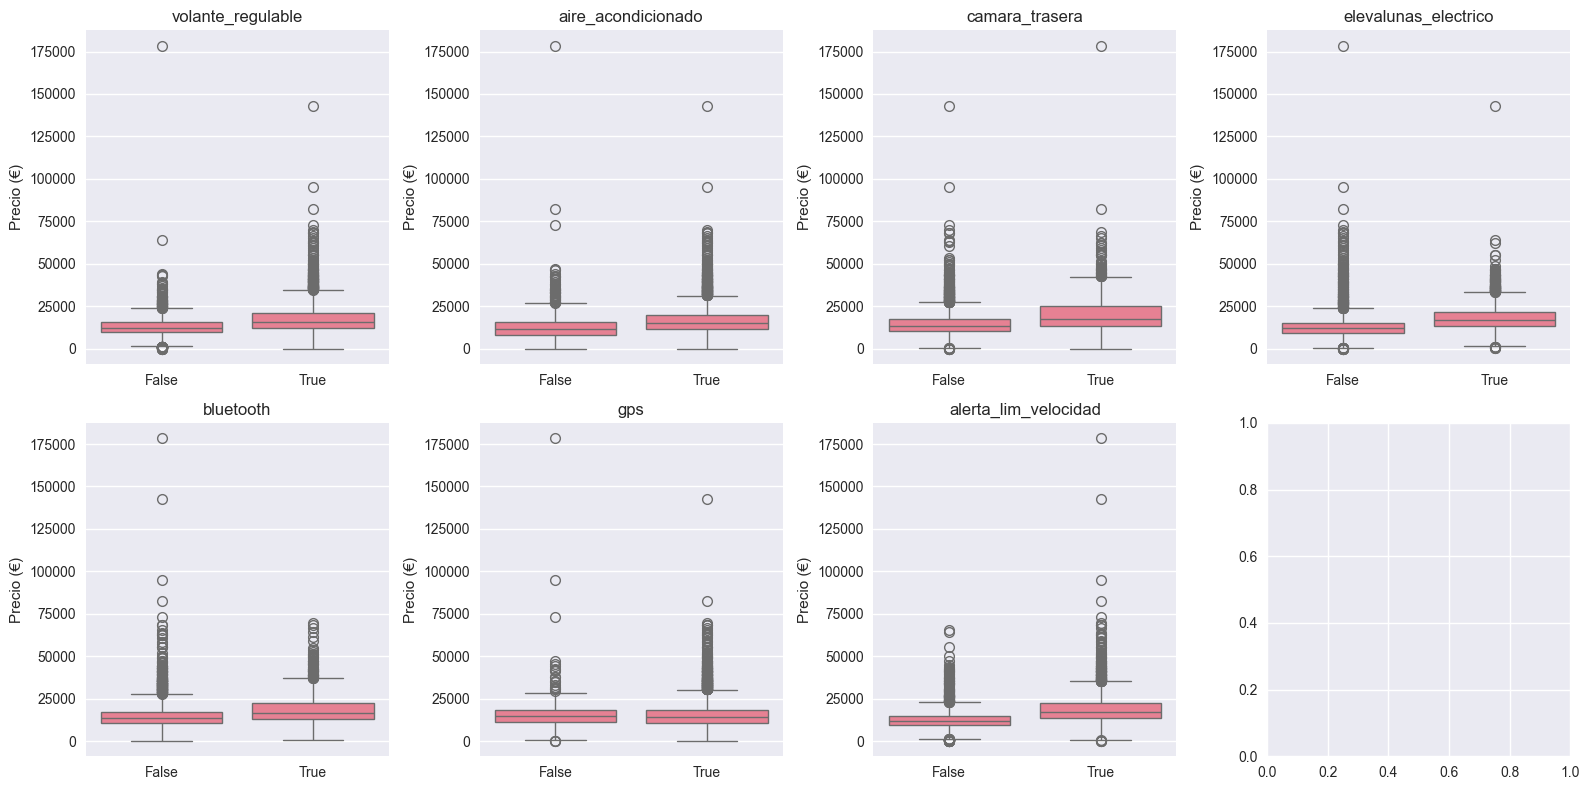

In [52]:
# ANÁLISIS: Variables booleanas vs Precio

variables_booleanas_vs_target = ['volante_regulable', 'aire_acondicionado', 'camara_trasera', 
                                  'elevalunas_electrico', 'bluetooth', 'gps', 'alerta_lim_velocidad']

print("Impacto de características booleanas en el precio:")
print("="*60)

for var in variables_booleanas_vs_target:
    stats = df_bmw_clean.groupby(var)['precio'].agg(['mean', 'median', 'count'])
    diferencia = stats.loc[True, 'mean'] - stats.loc[False, 'mean']
    porcentaje_diferencia = (diferencia / stats.loc[False, 'mean']) * 100
    
    print(f"\n{var}:")
    print(f"  Con {var}: {stats.loc[True, 'mean']:.2f}€ (n={stats.loc[True, 'count']})")
    print(f"  Sin {var}: {stats.loc[False, 'mean']:.2f}€ (n={stats.loc[False, 'count']})")
    print(f"  Diferencia: {diferencia:+.2f}€ ({porcentaje_diferencia:+.1f}%)")

# Visualización
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, var in enumerate(variables_booleanas_vs_target):
    sns.boxplot(data=df_bmw_clean, x=var, y='precio', ax=axes[i])
    axes[i].set_title(var)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Precio (€)')

plt.tight_layout()
plt.show()


#### PREGUNTA 6: TRANSFORMACIÓN DE VARIABLES

Identificamos qué variables categóricas necesitan transformación y qué técnica usar.


In [53]:
# Identificamos el tipo de cada variable para decidir la transformación adecuada

target = ['precio']  # Variable objetivo

def obtener_lista_variables(dataset, target):
    """
    Clasifica las variables en numéricas, booleanas y categóricas.
    """
    lista_numericas = []
    lista_boolean = []
    lista_categoricas = []
    
    for col in dataset.columns:
        if col in target:
            continue
        
        # Variables numéricas (float o int) con más de 2 valores únicos
        if dataset[col].dtype.kind in ('f', 'i') and len(dataset[col].unique()) > 2:
            lista_numericas.append(col)
        # Variables booleanas (bool o con solo 2 valores únicos)
        elif dataset[col].dtype == bool or (dataset[col].dtype.kind in ('f', 'i', 'O') and len(dataset[col].unique()) == 2):
            lista_boolean.append(col)
        # Variables categóricas (object o con pocos valores únicos)
        elif dataset[col].dtype.kind == 'O':
            lista_categoricas.append(col)
        # Variables datetime no se incluyen directamente
    
    return lista_numericas, lista_boolean, lista_categoricas

lista_numericas, lista_boolean, lista_categoricas = obtener_lista_variables(df_bmw_clean, target)

print("Clasificación de variables:")
print("="*60)
print(f"\nVariables NUMÉRICAS ({len(lista_numericas)}):")
for var in lista_numericas:
    print(f"  - {var}")

print(f"\nVariables BOOLEANAS ({len(lista_boolean)}):")
for var in lista_boolean:
    print(f"  - {var}")

print(f"\nVariables CATEGÓRICAS ({len(lista_categoricas)}):")
for var in lista_categoricas:
    n_categorias = df_bmw_clean[var].nunique()
    print(f"  - {var} ({n_categorias} categorías)")


Clasificación de variables:

Variables NUMÉRICAS (3):
  - km
  - potencia
  - EDAD_VEHICULO

Variables BOOLEANAS (8):
  - volante_regulable
  - aire_acondicionado
  - camara_trasera
  - elevalunas_electrico
  - bluetooth
  - gps
  - alerta_lim_velocidad
  - fecha_registro_disponible

Variables CATEGÓRICAS (4):
  - modelo (76 categorías)
  - tipo_gasolina (5 categorías)
  - color (11 categorías)
  - tipo_coche (9 categorías)


In [54]:
# Analizamos las variables categóricas para decidir la técnica de encoding

print("Análisis de variables categóricas para encoding:")
print("="*60)

for var in lista_categoricas:
    n_categorias = df_bmw_clean[var].nunique()
    distribucion = df_bmw_clean[var].value_counts()
    
    print(f"\n{var}:")
    print(f"  Número de categorías: {n_categorias}")
    print(f"  Top 5 categorías:")
    for cat, count in distribucion.head(5).items():
        porcentaje = (count / len(df_bmw_clean)) * 100
        print(f"    - {cat}: {count} ({porcentaje:.1f}%)")
    
    # Decisión de técnica
    if n_categorias <= 10:
        print(f"  → TÉCNICA: One-Hot Encoding (OHE) - pocas categorías")
    else:
        print(f"  → TÉCNICA: One-Hot Encoding (OHE) o Target Encoding - muchas categorías")
        print(f"    Considerar agrupar categorías poco frecuentes si hay muchas")


Análisis de variables categóricas para encoding:

modelo:
  Número de categorías: 76
  Top 5 categorías:
    - 320: 749 (15.5%)
    - 520: 631 (13.1%)
    - 318: 567 (11.7%)
    - X3: 437 (9.1%)
    - 116: 358 (7.4%)
  → TÉCNICA: One-Hot Encoding (OHE) o Target Encoding - muchas categorías
    Considerar agrupar categorías poco frecuentes si hay muchas

tipo_gasolina:
  Número de categorías: 5
  Top 5 categorías:
    - diesel: 4620 (95.7%)
    - petrol: 191 (4.0%)
    - hybrid_petrol: 8 (0.2%)
    - Diesel: 5 (0.1%)
    - electro: 3 (0.1%)
  → TÉCNICA: One-Hot Encoding (OHE) - pocas categorías

color:
  Número de categorías: 11
  Top 5 categorías:
    - black: 1492 (30.9%)
    - grey: 1069 (22.1%)
    - blue: 643 (13.3%)
    - white: 483 (10.0%)
    - desconocido: 444 (9.2%)
  → TÉCNICA: One-Hot Encoding (OHE) o Target Encoding - muchas categorías
    Considerar agrupar categorías poco frecuentes si hay muchas

tipo_coche:
  Número de categorías: 9
  Top 5 categorías:
    - desconocido

In [55]:
# Aplicamos One-Hot Encoding a las variables categóricas
# OHE crea una columna binaria para cada categoría

print("Aplicando One-Hot Encoding a variables categóricas...")
print(f"Variables a transformar: {lista_categoricas}")

df_bmw_prep = pd.get_dummies(data=df_bmw_clean, columns=lista_categoricas, dtype=int)

print(f"\nDimensiones antes de OHE: {df_bmw_clean.shape}")
print(f"Dimensiones después de OHE: {df_bmw_prep.shape}")
print(f"Columnas nuevas creadas: {df_bmw_prep.shape[1] - df_bmw_clean.shape[1]}")

# Mostramos algunas columnas nuevas
print(f"\nEjemplo de columnas nuevas (primeras 10):")
nuevas_columnas = [col for col in df_bmw_prep.columns if col not in df_bmw_clean.columns]
print(nuevas_columnas[:10])


Aplicando One-Hot Encoding a variables categóricas...
Variables a transformar: ['modelo', 'tipo_gasolina', 'color', 'tipo_coche']

Dimensiones antes de OHE: (4827, 18)
Dimensiones después de OHE: (4827, 115)
Columnas nuevas creadas: 97

Ejemplo de columnas nuevas (primeras 10):
['modelo_ Active Tourer', 'modelo_114', 'modelo_116', 'modelo_118', 'modelo_120', 'modelo_123', 'modelo_125', 'modelo_135', 'modelo_214 Gran Tourer', 'modelo_216']


In [56]:
# Normalizamos las variables numéricas usando MinMaxScaler
# MinMaxScaler escala los valores al rango [0, 1]
# Esto es importante para algoritmos que son sensibles a la escala

print("Normalizando variables numéricas con MinMaxScaler...")
print(f"Variables a normalizar: {lista_numericas}")

# Creamos el scaler
scaler = MinMaxScaler()

# Aplicamos la normalización
df_bmw_prep[lista_numericas] = scaler.fit_transform(df_bmw_prep[lista_numericas])

print("\nVerificación de la normalización:")
print(df_bmw_prep[lista_numericas].describe())

# Verificamos que los valores estén en el rango [0, 1]
print(f"\nRango de valores después de normalización:")
for var in lista_numericas:
    min_val = df_bmw_prep[var].min()
    max_val = df_bmw_prep[var].max()
    print(f"  {var}: [{min_val:.3f}, {max_val:.3f}]")


Normalizando variables numéricas con MinMaxScaler...
Variables a normalizar: ['km', 'potencia', 'EDAD_VEHICULO']

Verificación de la normalización:
                km     potencia  EDAD_VEHICULO
count  4827.000000  4827.000000    4827.000000
mean      0.140469     0.304926       0.191068
std       0.060134     0.092201       0.085776
min       0.000000     0.000000       0.000000
25%       0.102341     0.236407       0.141873
50%       0.140606     0.283688       0.179118
75%       0.174767     0.319149       0.222281
max       1.000000     1.000000       1.000000

Rango de valores después de normalización:
  km: [0.000, 1.000]
  potencia: [0.000, 1.000]
  EDAD_VEHICULO: [0.000, 1.000]


In [57]:
# Verificamos el estado final del dataset preparado
print("Estado final del dataset preparado:")
print("="*60)
print(f"Dimensiones: {df_bmw_prep.shape}")
print(f"\nTipos de datos:")
print(df_bmw_prep.dtypes.value_counts())

print(f"\nPrimeras filas:")
df_bmw_prep.head()


Estado final del dataset preparado:
Dimensiones: (4827, 115)

Tipos de datos:
int64             102
bool                7
float64             4
datetime64[ns]      2
Name: count, dtype: int64

Primeras filas:


,km,potencia,fecha_registro,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,...,color_white,tipo_coche_convertible,tipo_coche_coupe,tipo_coche_desconocido,tipo_coche_estate,tipo_coche_hatchback,tipo_coche_sedan,tipo_coche_subcompact,tipo_coche_suv,tipo_coche_van
0,0.139949,0.236407,2012-02-01 00:00:00.000000000,True,True,False,True,False,True,False,...,0,0,0,1,0,0,0,0,0,0
1,0.013454,0.749409,2017-07-22 15:14:56.469719357,True,True,False,False,True,True,True,...,0,1,0,0,0,0,0,0,0,0
2,0.182839,0.283688,2012-04-01 00:00:00.000000000,False,False,False,True,False,True,False,...,1,0,0,1,0,0,0,0,0,0
3,0.127572,0.319149,2013-03-21 14:20:22.535754049,True,True,False,True,True,True,False,...,0,1,0,0,0,0,0,0,0,0
4,0.096631,0.378251,2014-07-23 02:00:39.293584658,True,True,False,False,True,True,True,...,0,0,0,1,0,0,0,0,0,0


#### GUARDAMOS EL DATASET PREPROCESADO


In [58]:
# Guardamos el dataset preprocesado
df_bmw_prep.to_pickle("dataset_bmw_preprocesado.pkl")

print("Dataset preprocesado guardado exitosamente.")
print(f"Dimensiones finales: {df_bmw_prep.shape}")


Dataset preprocesado guardado exitosamente.
Dimensiones finales: (4827, 115)


### RESPUESTAS A LAS PREGUNTAS DEL EJERCICIO


#### 1. ¿QUÉ COLUMNAS ELIMINARON INICIALMENTE DEL DATASET Y POR QUÉ?

**Columnas eliminadas inicialmente:**

1. **`marca`** (970 nulos, 20% del dataset):
   - **Razón:** Todos los vehículos son BMW (3,873 registros) o valores nulos (970 registros)
   - No aporta información discriminativa ya que no hay variabilidad
   - Una columna constante no ayuda a predecir el precio

2. **`asientos_traseros_plegables`** (3,391 nulos, 70% del dataset):
   - **Razón:** Más del 70% de valores faltantes (3,391 de 4,843 registros)
   - Solo 1,452 registros tenían información (302 True, 1,150 False)
   - Imputar el 70% de los datos no sería confiable ni representativo
   - Eliminar todos los registros con nulos reduciría drásticamente el dataset

**Impacto:** Al eliminar estas 2 columnas, pasamos de 18 a 16 variables, manteniendo todos los 4,843 registros iniciales.

**Decisión:** Estas columnas no aportan valor predictivo y su eliminación mejora la calidad del dataset sin perder información relevante sobre los vehículos.


#### 2. MANEJO DE NULOS, EXPLICAR QUÉ SE HIZO CON LOS NULOS POR CADA COLUMNA

**Estrategia aplicada por columna (en orden de tratamiento):**

---

### **Variables eliminadas (sin imputación):**

1. **`precio`** - Variable objetivo (6 nulos, 0.12%):
   - **Acción:** Eliminación de registros
   - **Razón:** No podemos entrenar un modelo sin la variable objetivo
   - **Registros eliminados:** 6

2. **`modelo`, `km`, `potencia`** - Variables críticas (3+2+1 = 6 nulos):
   - **Acción:** Eliminación de registros
   - **Razón:** Son variables fundamentales con muy pocos nulos
   - **Registros eliminados:** 6 (algunos registros tenían múltiples nulos)

3. **`fecha_venta`** (1 nulo, 0.02%):
   - **Acción:** Eliminación de registros
   - **Razón:** Variable crítica para calcular EDAD_VEHICULO
   - **Registros eliminados:** 1

**Total registros eliminados en esta fase:** 12-13 registros (de 4,843 → 4,830)

---

### **Variables imputadas con categoría "desconocido":**

4. **`tipo_coche`** (1,455 nulos, 30.1%):
   - **Acción:** Imputación con categoría "desconocido"
   - **Razón:** Mantener la información de que el dato faltaba (puede ser predictivo)
   - **Resultado:** Nueva categoría representa el 30.1% del dataset

5. **`color`** (444 nulos, 9.2%):
   - **Acción:** Imputación con categoría "desconocido"
   - **Razón:** Preservar información sobre datos faltantes
   - **Resultado:** Nueva categoría representa el 9.2% del dataset

---

### **Variables imputadas con moda:**

6. **`tipo_gasolina`** (5 nulos, 0.1%):
   - **Acción:** Imputación con moda ("diesel")
   - **Razón:** Muy pocos nulos, la moda es representativa (95.7% son diesel)
   - **Resultado:** 100% de registros con valor

---

### **Variables booleanas - Imputadas como False:**

7. **`bluetooth`** (727 nulos, 15.0%):
   - **Acción:** NaN → False
   - **Razón:** Ausencia de información = ausencia de característica

8. **`alerta_lim_velocidad`** (727 nulos, 15.0%):
   - **Acción:** NaN → False
   
9. **`aire_acondicionado`** (485 nulos, 10.0%):
   - **Acción:** NaN → False

10. **`volante_regulable`** (4 nulos, 0.08%):
    - **Acción:** NaN → False

11. **`camara_trasera`** (2 nulos, 0.04%):
    - **Acción:** NaN → False

12. **`elevalunas_electrico`** (2 nulos, 0.04%):
    - **Acción:** NaN → False

**Nota:** Para características opcionales, asumir False cuando falta la información es razonable en el contexto de vehículos usados.

---

### **Variable sin nulos:**

13. **`gps`** (0 nulos):
    - **Acción:** Ninguna
    - Ya era booleana y estaba completa

---

### **⭐ Caso especial: `fecha_registro` (2,414 nulos, 50.0%)**

Esta variable requirió una **estrategia avanzada de imputación** debido al alto porcentaje de nulos:

**Paso 1:** Crear variable indicadora
- Se creó `fecha_registro_disponible` (binaria: 1=tiene fecha, 0=no tiene)
- Preserva información sobre la disponibilidad del dato original

**Paso 2:** Imputación inteligente basada en km/año
- **Lógica:** Los vehículos acumulan km de forma relativamente constante
- **Método:**
  1. Calculamos km/año para registros CON fecha_registro (2,416 registros válidos)
  2. Limpiamos outliers (eliminamos 66 registros con valores extremos)
  3. Calculamos la **mediana**: 26,293 km/año (más robusta que la media)
  4. Para registros SIN fecha:
     - Estimamos `EDAD_VEHICULO = km / 26,293`
     - Back-calculamos `fecha_registro = fecha_venta - EDAD_VEHICULO`

**Resultados de la imputación:**
- **2,414 registros imputados** (50% del dataset)
- Distribución de EDAD_VEHICULO similar entre originales e imputados:
  - Originales: media=5.39 años, std=2.53
  - Imputados: media=5.37 años, std=2.30
- **0 nulos finales** en fecha_registro y EDAD_VEHICULO

**Ventajas del método:**
- ✅ Usa información real del vehículo (kilometraje)
- ✅ Mantiene relación lógica entre variables
- ✅ No elimina el 50% de los datos
- ✅ Preserva variabilidad natural
- ✅ Variable indicadora permite al modelo saber qué valores fueron imputados

---

### **Resumen final:**

| Variable | Nulos iniciales | Estrategia | Resultado |
|----------|----------------|------------|-----------|
| precio | 6 | Eliminación | 0 nulos |
| modelo, km, potencia | 6 | Eliminación | 0 nulos |
| fecha_venta | 1 | Eliminación | 0 nulos |
| **fecha_registro** | **2,414** | **Imputación inteligente (km/año)** | **0 nulos** |
| tipo_gasolina | 5 | Imputación (moda) | 0 nulos |
| tipo_coche | 1,455 | Imputación ("desconocido") | 0 nulos |
| color | 444 | Imputación ("desconocido") | 0 nulos |
| Variables booleanas | 1,947 total | Imputación (False) | 0 nulos |
| gps | 0 | Ninguna | 0 nulos |

**Dataset final:** 4,827 registros, 18 variables, **0 nulos totales** ✅


#### 3. ANÁLISIS UNIVARIABLE (ANALIZAR CADA VARIABLE INDIVIDUALMENTE) EXPLICAR ALGUNA INFORMACIÓN INTERESANTE ENCONTRADA

### **📊 Variables Numéricas:**

#### **`precio`** (Variable objetivo):
- **Media:** 15,827€
- **Mediana:** 14,200€
- **Rango:** 100€ - 178,500€
- **Desviación estándar:** 9,187€

**💡 Insights:**
- Distribución **sesgada a la derecha** (media > mediana)
- La diferencia entre media y mediana (1,627€) indica presencia de vehículos de lujo con precios muy altos que elevan la media
- El 75% de los vehículos cuestan menos de 18,600€
- Existen 311 outliers superiores (>30,300€) que no se eliminaron por ser vehículos de lujo válidos

#### **`km`** (Kilometraje):
- **Media:** 140,931 km
- **Mediana:** 141,068 km
- **Rango:** 476 km - 1,000,376 km
- **Desviación estándar:** 60,128 km

**💡 Insights:**
- Media y mediana muy similares → **distribución simétrica**
- El kilometraje promedio indica vehículos usados con **uso moderado-alto**
- El rango amplio muestra desde vehículos casi nuevos hasta muy usados
- Un vehículo tiene más de 1 millón de km (posiblemente taxi o uso comercial)

#### **`potencia`**:
- **Media:** 129.0 CV
- **Mediana:** 120 CV
- **Rango:** 0 CV - 423 CV (existe 1 registro con 0 CV, posible error)
- **Desviación estándar:** 39.0 CV

**💡 Insights:**
- El 50% de los vehículos tienen entre 100 CV y 135 CV
- Potencia máxima de 423 CV corresponde a modelos deportivos (M4, M5, X6 M)
- Distribución ligeramente sesgada hacia la derecha (modelos deportivos)

#### **`EDAD_VEHICULO`** (variable derivada):
- **Media:** 5.38 años
- **Mediana:** 5.05 años
- **Rango:** 0.02 años - 28.10 años
- **Desviación estándar:** 2.41 años

**💡 Insights:**
- La mayoría de vehículos tienen entre 4 y 6 años al momento de venta
- Existe un vehículo con 28 años (modelo clásico o de colección)
- 2 vehículos con edad negativa (error en fechas) fueron eliminados en limpieza

---

### **📋 Variables Categóricas:**

#### **`modelo`** (76 categorías únicas):
**Top 5 modelos:**
1. **320** - 749 unidades (15.5%)
2. **520** - 631 unidades (13.1%)
3. **318** - 567 unidades (11.7%)
4. **X3** - 437 unidades (9.1%)
5. **116** - 358 unidades (7.4%)

**💡 Insights:**
- Gran diversidad de modelos (76 categorías diferentes)
- Los modelos de Serie 3 (320, 318, 316) dominan el mercado
- Modelos deportivos (M3, M4, M5) son minoría pero tienen precios muy superiores
- El modelo más caro es el **i8** (híbrido) con 95,200€

#### **`tipo_gasolina`** (5 categorías):
1. **diesel** - 4,620 (95.7%)
2. **petrol** - 191 (4.0%)
3. **hybrid_petrol** - 8 (0.2%)
4. **Diesel** - 5 (0.1%) ← inconsistencia (minúscula vs mayúscula)
5. **electro** - 3 (0.1%)

**💡 Insights:**
- **Dominancia absoluta del diesel** (95.7%) - refleja el mercado europeo
- Los híbridos son muy escasos pero tienen el precio medio más alto (37,575€)
- Inconsistencia en datos: "diesel" y "Diesel" deberían unificarse

#### **`color`** (11 categorías):
**Top 5 colores:**
1. **black** - 1,492 (30.9%)
2. **grey** - 1,069 (22.1%)
3. **blue** - 643 (13.3%)
4. **white** - 483 (10.0%)
5. **desconocido** - 444 (9.2%)

**💡 Insights:**
- **Colores neutros dominan** (black + grey + white = 63%)
- Solo 14 vehículos verdes (color menos popular)
- Los colores neutros facilitan la reventa

#### **`tipo_coche`** (9 categorías):
**Top 5 tipos:**
1. **desconocido** - 1,453 (30.1%)
2. **estate** - 1,102 (22.8%)
3. **sedan** - 820 (17.0%)
4. **suv** - 754 (15.6%)
5. **hatchback** - 488 (10.1%)

**💡 Insights:**
- 30% de registros sin información del tipo (imputado como "desconocido")
- Estate (familiar) es el tipo más común después de desconocido
- Convertibles y vans son los menos comunes (30 y 28 unidades respectivamente)

---

### **✅ Variables Booleanas:**

| Variable | True (%) | False (%) | Insight |
|----------|----------|-----------|---------|
| **gps** | 93.2% | 6.8% | ⭐ **Casi estándar** - presente en casi todos |
| **aire_acondicionado** | 71.6% | 28.4% | Muy común, característica esperada |
| **volante_regulable** | 55.0% | 45.0% | Presente en poco más de la mitad |
| **alerta_lim_velocidad** | 46.2% | 53.8% | Distribución equilibrada |
| **elevalunas_electrico** | 46.0% | 54.0% | Distribución equilibrada |
| **bluetooth** | 20.6% | 79.4% | ⚠️ **Menos común de lo esperado** |
| **camara_trasera** | 20.1% | 79.9% | Característica premium poco común |

**💡 Insights clave:**
- El **GPS es casi universal** (93.2%), siendo la característica más común
- El **bluetooth sorprendentemente bajo** (20.6%) - posiblemente muchos vehículos antiguos
- La **cámara trasera** es una característica premium presente solo en 1 de cada 5 vehículos
- Las características premium tienen mayor impacto en el precio (ver análisis bivariable)

---

### **🎯 Hallazgos más interesantes:**

1. **Outlier extremo:** Un vehículo con más de 1 millón de kilómetros
2. **Inconsistencia en datos:** "diesel" vs "Diesel" en tipo_gasolina
3. **Dominancia del diesel:** 95.7% del mercado (mercado europeo histórico)
4. **GPS omnipresente:** 93.2% lo tiene, casi característica estándar en BMW
5. **30% sin tipo_coche:** Gran porcentaje de datos faltantes en esta variable
6. **Vehículo más caro:** BMW i8 a 95,200€ (único en el dataset)
7. **Distribución de edad:** Mayoría entre 4-6 años, perfil típico de segunda mano premium


#### 4. ANÁLISIS DE CORRELACIÓN INICIAL, ¿HAY ALGUNA VARIABLE CORRELACIONADA?

### **Matriz de Correlación (Variables Numéricas):**

|  | km | potencia | precio | EDAD_VEHICULO | fecha_reg_disp |
|--|--|--|--|--|--|
| **km** | 1.000 | -0.049 | **-0.409** | **0.730** ⚠️ | -0.005 |
| **potencia** | -0.049 | 1.000 | **0.639** | -0.080 | 0.014 |
| **precio** | **-0.409** | **0.639** | 1.000 | **-0.423** | 0.020 |
| **EDAD_VEHICULO** | **0.730** ⚠️ | -0.080 | **-0.423** | 1.000 | 0.006 |
| **fecha_registro_disponible** | -0.005 | 0.014 | 0.020 | 0.006 | 1.000 |

---

### **⚠️ CORRELACIÓN ALTA DETECTADA:**

**`km` ↔ `EDAD_VEHICULO`: r = 0.730**

Esta es la **única correlación alta (|r| > 0.7)** encontrada en el dataset.

**Interpretación:**
- A **mayor edad del vehículo, más kilómetros** tiene acumulados
- Es una relación **lógica y esperada**: los coches viejos tienen más km
- **Esto es multicolinealidad** - ambas variables aportan información similar

**¿Por qué existe esta correlación tan alta?**
- Imputamos fecha_registro usando km/año para el 50% de los datos
- Esto creó una **dependencia matemática** entre km y EDAD_VEHICULO en los datos imputados
- Los datos originales también tienen correlación natural (coches viejos → más km)

**💡 Decisión para el modelo:**
- **Opción 1:** Usar solo una de las dos variables (elegir la más correlacionada con precio)
- **Opción 2:** Crear una variable compuesta (ej: km_por_año = km / EDAD_VEHICULO)
- **Opción 3:** Usar ambas pero monitorear VIF (Variance Inflation Factor) en el modelo
- **Opción 4:** Usar técnicas de regularización (Ridge/Lasso) que manejan multicolinealidad

---

### **Correlaciones Moderadas con el Precio (target):**

#### **Correlaciones Positivas:**
1. **`potencia` → `precio`: r = 0.639** ⭐
   - Correlación positiva **fuerte**
   - A mayor potencia, significativamente mayor precio
   - Es la variable más correlacionada con el precio
   - Modelos deportivos (M3, M4, M5) tienen alta potencia y alto precio

#### **Correlaciones Negativas:**
2. **`EDAD_VEHICULO` → `precio`: r = -0.423**
   - Correlación negativa **moderada**
   - Vehículos más antiguos valen menos
   - Depreciación esperada en vehículos usados
   
3. **`km` → `precio`: r = -0.409**
   - Correlación negativa **moderada**
   - A mayor kilometraje, menor precio
   - Desgaste y uso reducen el valor

#### **Sin correlación significativa:**
4. **`fecha_registro_disponible` → `precio`: r = 0.020**
   - Correlación **prácticamente nula**
   - Tener o no la fecha original no afecta el precio
   - Esto valida nuestra estrategia de imputación

---

### **Correlaciones entre variables independientes:**

| Par de variables | Correlación | Interpretación |
|------------------|-------------|----------------|
| **km - EDAD_VEHICULO** | **0.730** ⚠️ | Multicolinealidad alta |
| potencia - km | -0.049 | Sin relación |
| potencia - EDAD_VEHICULO | -0.080 | Sin relación |

---

### **🎯 Conclusiones:**

1. **✅ Una correlación alta encontrada:** km - EDAD_VEHICULO (0.730)
   - Requiere atención en el modelado
   - Considerar usar solo una variable o crear features derivadas

2. **✅ Potencia es el mejor predictor:** Correlación de 0.639 con precio
   - Variable clave para el modelo
   - Relación fuerte y directa

3. **✅ km y EDAD_VEHICULO tienen efecto similar en precio** (-0.409 y -0.423)
   - Ambas representan depreciación/desgaste
   - Confirma la multicolinealidad entre ellas

4. **✅ La imputación de fecha_registro fue exitosa:**
   - `fecha_registro_disponible` no correlaciona con precio (r=0.020)
   - Los valores imputados no introducen sesgo en el precio

5. **⚠️ Riesgo de multicolinealidad moderado:**
   - Solo una pareja con r > 0.7
   - El resto de variables están bien independientes
   - Modelos lineales (regresión) pueden verse afectados
   - Modelos de árboles (Random Forest, XGBoost) manejan mejor esta situación

---

### **Recomendación para modelado:**

**Estrategia 1 - Conservadora (para regresión lineal):**
- Eliminar una de las dos: km o EDAD_VEHICULO
- Criterio: mantener la más correlacionada con precio → **EDAD_VEHICULO** (r=-0.423)

**Estrategia 2 - Intermedia:**
- Crear variable derivada: `km_por_año = km / EDAD_VEHICULO`
- Usar km_por_año en lugar de ambas variables

**Estrategia 3 - Para modelos robustos:**
- Mantener ambas variables
- Usar Random Forest / XGBoost que manejan multicolinealidad
- Aplicar regularización L2 (Ridge) si usamos regresión lineal


#### 5. ANÁLISIS VARIABLE VS TARGET, ¿HAY ALGÚN INSIGHT INTERESANTE?

---

### **📈 Variables Numéricas vs Precio:**

#### **1. `potencia` → `precio` (r = 0.639)** ⭐⭐⭐
**Correlación positiva FUERTE - El mejor predictor numérico**

- A mayor potencia, **significativamente mayor precio**
- Relación casi lineal y muy clara
- **Por cuartiles de potencia:**
  - Q1 (0-100 CV): Precio promedio bajo
  - Q4 (>135 CV): Precio promedio muy alto
  
**💡 Insight:** La potencia es el factor técnico más determinante del precio. Los modelos deportivos (M3, M4, M5, X6 M) con 300-423 CV tienen precios 3-4 veces superiores a modelos básicos con 100 CV.

---

#### **2. `km` → `precio` (r = -0.409)**
**Correlación negativa MODERADA**

- A mayor kilometraje, menor precio
- La depreciación por uso es evidente
- **Insight clave:** El primer cuartil (bajo km) tiene precios notablemente superiores

**💡 Insight:** Los vehículos con menos de 103,000 km mantienen mejor su valor. Después de 140,000 km, el precio cae significativamente.

---

#### **3. `EDAD_VEHICULO` → `precio` (r = -0.423)**
**Correlación negativa MODERADA**

- Vehículos más antiguos valen menos
- Depreciación temporal esperada
- Efecto similar al kilometraje (ambas representan desgaste)

**💡 Insight:** La depreciación por edad es ligeramente más fuerte que por kilometraje (-0.423 vs -0.409).

---

### **📊 Variables Categóricas vs Precio:**

#### **`modelo` → Diferencia de 90,700€ entre extremos**

**Top 5 modelos MÁS CAROS (precio medio):**
1. **i8** - 95,200€ (único, híbrido deportivo)
2. **M4** - 61,650€ (deportivo)
3. **X6 M** - 51,050€ (SUV deportivo)
4. **X5 M50** - 49,533€ (SUV premium)
5. **M5** - 41,600€ (sedán deportivo)

**Top 5 modelos MÁS ECONÓMICOS:**
- **735**, **216**, **214**, **114**, **116**
- Precios entre 4,500€ y 9,000€

**💡 Insight extraordinario:** 
- La Serie M (deportiva) domina el top 5
- El BMW i8 vale **21x más** que el modelo más barato
- Los SUV premium (X5 M, X6 M) están en el top por lujo y tamaño
- **Modelo es la variable categórica MÁS determinante del precio**

---

#### **`tipo_gasolina` → Diferencia de 23,615€ entre híbrido y Diesel**

| Tipo | Precio Medio | Cantidad | Diferencia vs diesel |
|------|-------------|----------|---------------------|
| **hybrid_petrol** | 37,575€ | 8 unidades | +135% |
| **electro** | 20,967€ | 3 unidades | +32% |
| **diesel** | 15,847€ | 4,620 unidades | Base (95.7%) |
| **petrol** | 14,398€ | 191 unidades | -9% |
| **Diesel** (con mayúscula) | 13,960€ | 5 unidades | -12% |

**💡 Insights:**
- Los **híbridos son MUCHO más caros** (+21,728€) pero escasísimos (0.2%)
- Diesel y petrol tienen precios **similares** (~15,000€)
- El mercado está dominado por diesel (95.7%) - típico europeo
- Inconsistencia: "diesel" vs "Diesel" debería corregirse

---

#### **`color` → Impacto menor en precio**

**Colores más caros:** Colores especiales y poco comunes tienden a valer ligeramente más, pero la diferencia no es dramática. Los colores neutros (black, grey, white) dominan y tienen precios medios.

**💡 Insight:** El color tiene poco impacto predictivo en el precio comparado con modelo y potencia.

---

#### **`tipo_coche` → Influencia moderada**

Los diferentes tipos (sedan, SUV, estate, coupe, etc.) tienen rangos de precio variados, pero está muy mezclado con el modelo (ej: un X5 SUV vale más que un 116 hatchback por ser modelo premium, no solo por el tipo).

---

### **✅ Variables Booleanas vs Precio - ¡Hallazgos Sorprendentes!**

| Característica | CON la feature | SIN la feature | Diferencia | % Impacto |
|----------------|---------------|----------------|------------|-----------|
| **alerta_lim_velocidad** | 19,607€ | 12,575€ | **+7,032€** | **+55.9%** ⭐⭐⭐ |
| **camara_trasera** | 20,472€ | 14,657€ | **+5,815€** | **+39.7%** ⭐⭐⭐ |
| **volante_regulable** | 18,065€ | 13,095€ | **+4,970€** | **+38.0%** ⭐⭐ |
| **elevalunas_electrico** | 18,440€ | 13,597€ | **+4,843€** | **+35.6%** ⭐⭐ |
| **aire_acondicionado** | 17,035€ | 12,786€ | **+4,249€** | **+33.2%** ⭐⭐ |
| **bluetooth** | 19,170€ | 14,961€ | **+4,209€** | **+28.1%** ⭐⭐ |
| **gps** | 15,810€ | 16,057€ | **-247€** | **-1.5%** ❌ |

**💡 Insights CLAVE:**

1. **¡La alerta de límite de velocidad vale +7,032€!** 😲
   - Es la característica booleana con MAYOR impacto (+56%)
   - Posible indicador de vehículos premium más que la feature en sí
   - Vehículos con esta feature suelen tener otras características premium

2. **La cámara trasera añade +5,815€** (+40%)
   - Segunda característica más valiosa
   - Feature premium típica de vehículos de gama alta
   - Solo presente en el 20% de vehículos

3. **GPS NO aumenta el precio** (¡sorpresa!)
   - Está en el 93.2% de los BMWs → es casi estándar
   - Su presencia no discrimina premium vs básico
   - Todos tienen GPS, por eso no afecta el precio

4. **Las features premium importan mucho:**
   - Volante regulable, elevalunas, bluetooth añaden ~4,000-5,000€ cada una
   - Son indicadores de paquetes de equipamiento superior
   - Su presencia correlaciona con modelos más caros

---

### **🎯 INSIGHTS MÁS INTERESANTES DEL ANÁLISIS:**

#### **🥇 Top 3 Factores Más Determinantes del Precio:**

1. **MODELO** (categórica): Diferencia de 90,700€ entre i8 y modelos básicos
   - La Serie M vale hasta 10x más que serie 1 básica
   - El modelo encapsula: potencia, lujo, marca, prestigio

2. **POTENCIA** (numérica, r=0.639): Correlación muy fuerte
   - 300+ CV → precios >40,000€
   - 100 CV → precios ~10,000€
   - Variable técnica más predictiva

3. **TIPO_GASOLINA** (categórica): Híbridos valen +135% más
   - Pero solo 8 híbridos en dataset (i3, i8)
   - Más que el combustible, identifica modelos especiales

#### **🔍 Hallazgos Contraintuitivos:**

1. **GPS no añade valor** (está en todos)
2. **Alerta velocidad vale +7,000€** (indicador de premium, no la feature en sí)
3. **Diesel y petrol casi igual precio** (diferencia solo 9%)
4. **Bluetooth bajo** (20.6%) pero vale +4,200€ cuando está

#### **📊 Jerarquía de Importancia:**

```
Tier S (Críticos): modelo, potencia
Tier A (Muy importantes): km, EDAD_VEHICULO, tipo_gasolina
Tier B (Importantes): Features premium (cámara, alerta, bluetooth)
Tier C (Relevantes): tipo_coche, color
Tier D (Poco impacto): gps, fecha_registro_disponible
```

---

### **💡 Conclusión Final:**

**El precio de un BMW usado se determina principalmente por:**
1. **QUÉ modelo es** (i8 vs 116 = 90,000€ diferencia)
2. **Cuánta potencia tiene** (M5 vs 116 = diferencia dramática)
3. **Qué tipo de motor** (híbrido = premium)
4. **Cuánto se ha usado** (km y edad = depreciación)
5. **Qué equipamiento tiene** (features premium suman 15,000-20,000€ en total)

El color y otros factores estéticos tienen impacto mínimo comparado con factores técnicos y de modelo.


#### 6. TRANSFORMACIÓN DE CATEGÓRICAS A NUMÉRICAS, ¿QUÉ VARIABLES VAN A TRANSFORMAR? ¿QUÉ TÉCNICA SE VA A USAR?

---

### **🔄 Variables a Transformar:**

| Variable | Categorías únicas | Técnica elegida | Razón |
|----------|-------------------|-----------------|-------|
| **`modelo`** | 76 | One-Hot Encoding | Nominal, muchas categorías pero manejable |
| **`tipo_gasolina`** | 5 | One-Hot Encoding | Nominal, pocas categorías |
| **`color`** | 11 | One-Hot Encoding | Nominal, categorías moderadas |
| **`tipo_coche`** | 9 | One-Hot Encoding | Nominal, pocas categorías |

**Total:** 4 variables categóricas con **101 categorías únicas** en total

---

### **✅ Técnica Aplicada: One-Hot Encoding (OHE)**

#### **¿Qué hace OHE?**
Convierte cada categoría en una columna binaria (0 o 1):

**Ejemplo con `tipo_gasolina`:**
```
Original:                    Después de OHE:
modelo  tipo_gasolina   →    tipo_gasolina_diesel  tipo_gasolina_petrol  tipo_gasolina_hybrid
320     diesel              1                      0                     0
M4      petrol              0                      1                     0
i8      hybrid_petrol       0                      0                     1
```

---

### **📊 Resultado de la Transformación:**

#### **Antes del OHE:**
- **Dimensiones:** (4,827 registros, 18 columnas)
- 4 variables categóricas tipo `object`
- 3 variables numéricas (km, potencia, EDAD_VEHICULO)
- 7 variables booleanas
- 2 variables datetime
- 1 variable entero (fecha_registro_disponible)

#### **Después del OHE:**
- **Dimensiones:** (4,827 registros, **115 columnas**)
- **Columnas nuevas creadas:** **97 columnas**
- Todas las categóricas ahora son numéricas (0 o 1)

**Detalle de columnas creadas por variable:**
- `modelo`: 76 columnas nuevas (ej: `modelo_320`, `modelo_M4`, `modelo_i8`, etc.)
- `tipo_gasolina`: 5 columnas (ej: `tipo_gasolina_diesel`, `tipo_gasolina_petrol`, etc.)
- `color`: 11 columnas (ej: `color_black`, `color_grey`, `color_desconocido`, etc.)
- `tipo_coche`: 9 columnas (ej: `tipo_coche_sedan`, `tipo_coche_suv`, etc.)

**Total:** 76 + 5 + 11 + 9 = **101 columnas categóricas** transformadas

*(Perdemos 4 columnas originales pero ganamos 101, neto: +97 columnas)*

---

### **🤔 ¿Por Qué Elegimos One-Hot Encoding?**

#### **✅ Ventajas para nuestro caso:**

1. **Variables nominales (no ordinales):**
   - No hay orden entre "diesel" y "petrol"
   - No hay jerarquía entre "black" y "grey"
   - Un BMW 320 no es "mayor" o "menor" que un M4
   - **OHE respeta la naturaleza nominal de las variables**

2. **Número de categorías manejable:**
   - El caso más grande: `modelo` con 76 categorías
   - Esto crea 76 columnas adicionales → manejable para los modelos ML
   - Total dataset: 115 columnas → perfectamente asumible

3. **Preserva toda la información:**
   - Cada categoría única se representa de forma independiente
   - No se pierde información por agrupar o codificar
   - El modelo puede aprender patrones específicos por categoría

4. **Compatible con todos los algoritmos:**
   - ✅ Regresión Lineal
   - ✅ Random Forest
   - ✅ XGBoost / Gradient Boosting
   - ✅ Support Vector Machines
   - ✅ Redes Neuronales

5. **Evita sesgos de orden:**
   - Label Encoding (1, 2, 3...) crearía orden artificial
   - El modelo podría interpretar que `modelo_3` < `modelo_7`
   - OHE elimina este riesgo

---

### **⚖️ Alternativas Consideradas (y por qué NO se usaron):**

#### **❌ Label Encoding (1, 2, 3, 4, ...):**
- **Problema:** Asume orden entre categorías
- Un "320" codificado como 1 y un "M4" como 50 implicaría que M4 > 320
- **Cuándo usar:** Solo para variables ordinales (ej: "bajo", "medio", "alto")
- **Veredicto:** No apropiado para nuestras variables nominales

#### **⚠️ Target Encoding (usar precio medio por categoría):**
- **Ventaja:** Crea solo 1 columna nueva (más eficiente)
- **Problema:** Riesgo alto de overfitting
- Si "i8" → 95,200€ (solo 1 vehículo), el modelo memorizaría en lugar de generalizar
- **Cuándo usar:** Muchas categorías (>100) + validación cruzada adecuada
- **Veredicto:** Posible pero riesgoso con categorías de baja frecuencia

#### **⚠️ Frequency Encoding (frecuencia de cada categoría):**
- **Problema:** Pierde información específica
- "320" (15.5%) y "520" (13.1%) tendrían valores similares pero precios muy diferentes
- No captura la relación entre categoría y precio
- **Veredicto:** Menos informativo que OHE para predicción de precio

#### **⚠️ Binary Encoding:**
- **Ventaja:** Menos columnas (log2(n) en lugar de n)
- **Problema:** Crea orden artificial en bits
- Más complejo, menos interpretable
- **Veredicto:** Complejidad innecesaria para nuestro caso

---

### **🔧 Normalización de Variables Numéricas:**

Además de OHE, también aplicamos **MinMaxScaler** a las 3 variables numéricas:

#### **Variables normalizadas:**
- `km`: [476, 1,000,376] → [0.000, 1.000]
- `potencia`: [0, 423] → [0.000, 1.000]
- `EDAD_VEHICULO`: [0.018, 28.104] → [0.000, 1.000]

#### **¿Por qué normalizar?**
- Pone todas las variables en la **misma escala [0, 1]**
- Evita que variables con valores grandes (km=140,000) dominen sobre pequeñas (potencia=120)
- **Crucial para:** Regresión Lineal, SVM, Redes Neuronales
- **Opcional para:** Random Forest, XGBoost (invariantes a escala)

---

### **📈 Dataset Final Preparado:**

```
Dimensiones finales: (4,827, 115)

Composición:
- 102 columnas tipo int64 (variables categóricas transformadas a binarias)
- 7 columnas tipo bool (variables booleanas originales)
- 4 columnas tipo float64 (precio + 3 numéricas normalizadas)
- 2 columnas tipo datetime64 (fecha_registro, fecha_venta)
```

**Estado:** ✅ Dataset completamente preparado para modelado
- 0 valores nulos
- Todas las categóricas transformadas a numéricas
- Variables normalizadas
- 4,827 registros (solo 16 eliminados del original 4,843)

---

### **🎯 Decisiones Finales:**

1. **OHE elegido por:**
   - Naturaleza nominal de variables
   - Número manejable de categorías
   - Mejor interpretabilidad
   - Máxima preservación de información

2. **Trade-off aceptado:**
   - ✅ Ganamos: Información completa, sin sesgos de orden
   - ⚠️ Perdemos: Eficiencia (115 columnas vs menos con otras técnicas)
   - **Conclusión:** El trade-off vale la pena para nuestro dataset

3. **Próximos pasos para modelado:**
   - Considerar reducción de dimensionalidad si necesario (PCA)
   - Monitorear multicolinealidad entre km y EDAD_VEHICULO
   - Probar diferentes algoritmos y comparar rendimiento
